# Finviz Burst → T+1…T+9 Analysis — v2 (Corrected Methodology)

## What changed vs v1

| Issue | v1 (original) | v2 (this notebook) |
|-------|--------------|--------------------|
| **Return metric** | `(T+N_close - trigger) / trigger` for ALL events | Conditional on trigger being hit (`T+N_high >= trigger`); fill = `max(open, trigger)` |
| **Unconditional entry** | Not separated | Explicit "open entry" scenario for comparison |
| **burst_chg** | Mean of Finviz snapshot change_pct | IBKR actual close change vs prior close |
| **Multiple testing** | None | FDR correction (Benjamini-Hochberg) across T+1..T+9 |
| **CI on means** | None | 95% bootstrap CI |
| **Bounce day (Sec 8)** | Look-ahead (needs bottom known in advance) | Prospective definition: detectable at close of candidate day |
| **Risk metrics** | None | Sharpe, Kelly, max drawdown, CVaR |
| **Trigger hit rate** | Not measured | Explicit analysis |

## Hypotheses

| # | Hypothesis | Mechanism |
|---|-----------|----------|
| H1 | **Momentum continuation** | Persistent Finviz presence = institutional awareness → follow-through T+1/T+2 |
| H2 | **Mean reversion post-burst** | Overextension → T+2 onwards decay |
| H3 | **Candle quality filter** | Green + low wick + high close_pos → better entries |
| H4 | **Persistence intensity** | Higher presence_pct = more sustained → stronger edge |
| H5 | **Bounce day** | After dump phase, prospective recovery signal (green body + close_pos > 0.6) |

## Known Limitations
- **Universe bias**: only 13 days (2026-03-24 to 2026-04-13) when finviz-dashboard was running
- **N is small**: 95 burst events — all results are **exploratory**, not confirmatory
- All conclusions require replication on a larger dataset
- Transaction costs not included in gross returns (add ~$0.012/share per side)

In [166]:
import warnings
warnings.filterwarnings('ignore')

import sqlite3
import json
import time
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats as scipy_stats
from scipy.stats import bootstrap

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'figure.titlesize': 13,
})

ANALYSIS_DIR = Path('/Users/carlos/proyectos/TRADING/1_PROYECTOS_ACTIVOS/CLAUDE/finviz-dashboard/analysis')
DB_FV  = Path.home() / 'Library/Application Support/finviz-dashboard/finviz_snapshots.db'
DB_TS  = Path('/Users/carlos/proyectos/TRADING/1_PROYECTOS_ACTIVOS/CLAUDE/trading_system_v3/trader_engine/db/trader_engine.db')
CACHE  = ANALYSIS_DIR / 'burst_price_cache.csv'

print(f'Run date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'DB Finviz: {DB_FV.exists()}')
print(f'DB System: {DB_TS.exists()}')
print(f'Price cache: {CACHE.exists()}')

Run date: 2026-04-14 08:04:24
DB Finviz: True
DB System: True
Price cache: True


## 1. Build Burst Universe

In [167]:
# ── Load Finviz snapshots ────────────────────────────────────────────────────
conn = sqlite3.connect(DB_FV)
fv = pd.read_sql('SELECT * FROM snapshots WHERE category="Top Gainers" ORDER BY timestamp', conn)
conn.close()

fv['ts']        = pd.to_datetime(fv['timestamp'], utc=True).dt.tz_convert('US/Eastern')
fv['date']      = fv['ts'].dt.date
fv['snap']      = fv['ts'].dt.floor('15min')
fv['chg']       = pd.to_numeric(fv['change_pct'].str.replace('%','',regex=False), errors='coerce')
fv['price_num'] = pd.to_numeric(fv['price'], errors='coerce')

snaps_per_day = fv.groupby('date')['snap'].nunique().rename('total_snaps')

persist = fv.groupby(['date','ticker']).agg(
    n_snaps           = ('snap',      'nunique'),
    fv_chg_mean       = ('chg',       'mean'),    # Finviz snapshot mean (informational only)
    fv_price_first    = ('price_num', 'first'),
    fv_price_last     = ('price_num', 'last'),
    first_appearance  = ('ts',        'min'),
    last_appearance   = ('ts',        'max'),
).reset_index()

persist = persist.merge(snaps_per_day.reset_index(), on='date')
persist['presence_pct'] = persist['n_snaps'] / persist['total_snaps']
persist['burst_date']   = pd.to_datetime(persist['date'])

# Burst threshold: ≥30% of day's snapshots AND ≥3 absolute
PRESENCE_THRESH = 0.30
MIN_SNAPS       = 3
burst = persist[(persist['presence_pct'] >= PRESENCE_THRESH) & (persist['n_snaps'] >= MIN_SNAPS)].copy()
burst = burst.reset_index(drop=True)

print(f'Finviz data: {fv["date"].nunique()} days ({fv["date"].min()} → {fv["date"].max()})')
print(f'Burst events (presence≥{PRESENCE_THRESH:.0%}, n_snaps≥{MIN_SNAPS}): {len(burst)}')
print(f'Unique tickers: {burst["ticker"].nunique()}')
print()
print('Events per day:')
print(burst.groupby('date').size().to_string())

Finviz data: 13 days (2026-03-24 → 2026-04-13)
Burst events (presence≥30%, n_snaps≥3): 95
Unique tickers: 82

Events per day:
date
2026-03-24    7
2026-03-25    6
2026-03-26    8
2026-03-27    7
2026-03-30    7
2026-04-01    8
2026-04-02    7
2026-04-06    8
2026-04-07    8
2026-04-08    8
2026-04-09    7
2026-04-10    7
2026-04-13    7


2026-04-14 08:04:24,635 matplotlib.category INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-14 08:04:24,645 matplotlib.category INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


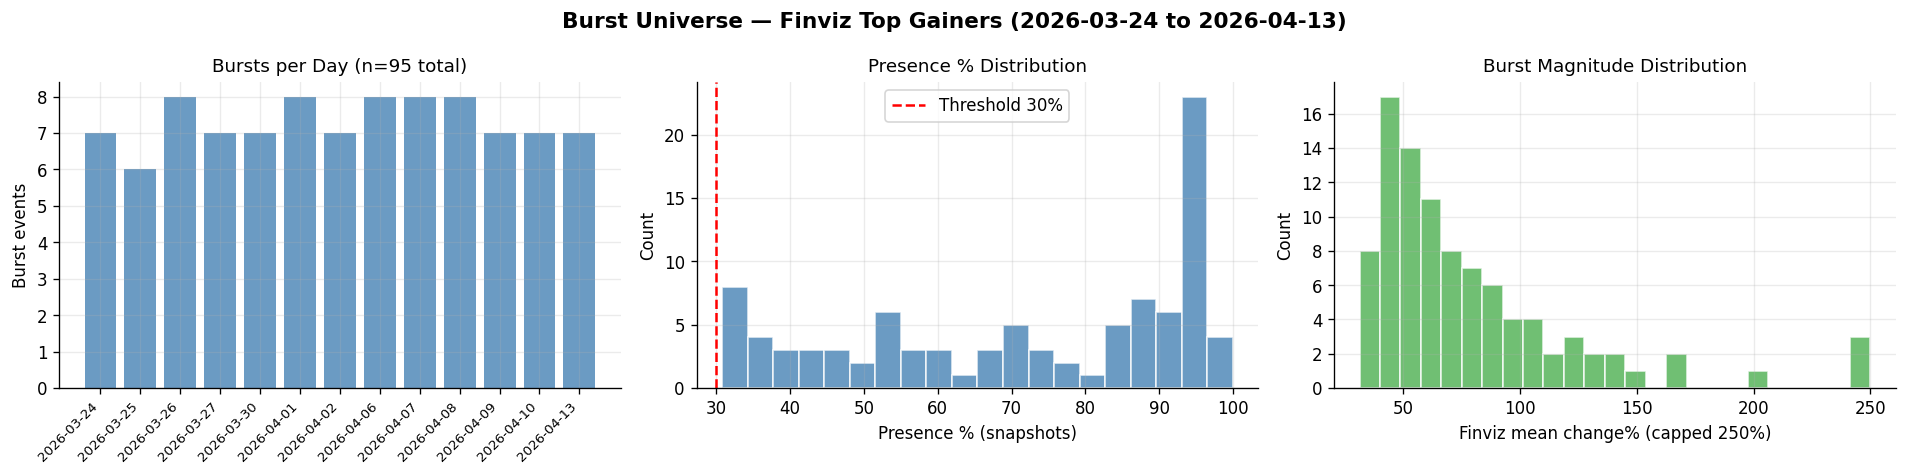

In [168]:
# ── Universe Visualization ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Burst Universe — Finviz Top Gainers (2026-03-24 to 2026-04-13)', fontweight='bold')

ax = axes[0]
per_day = burst.groupby('date').size()
ax.bar([str(d) for d in per_day.index], per_day.values, color='steelblue', alpha=0.8)
ax.set_xticklabels([str(d) for d in per_day.index], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Burst events')
ax.set_title(f'Bursts per Day (n={len(burst)} total)')

ax = axes[1]
ax.hist(burst['presence_pct']*100, bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(PRESENCE_THRESH*100, color='red', linestyle='--', label=f'Threshold {PRESENCE_THRESH:.0%}')
ax.set_xlabel('Presence % (snapshots)')
ax.set_ylabel('Count')
ax.set_title('Presence % Distribution')
ax.legend()

ax = axes[2]
ax.hist(burst['fv_chg_mean'].clip(0, 250), bins=25, color='#4CAF50', alpha=0.8, edgecolor='white')
ax.set_xlabel('Finviz mean change% (capped 250%)')
ax.set_ylabel('Count')
ax.set_title('Burst Magnitude Distribution')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'v2_fig01_universe.png', bbox_inches='tight')
plt.show()

## 2. Download / Refresh Price Data from IBKR

In [169]:
# ── Load existing cache ──────────────────────────────────────────────────────
if CACHE.exists():
    prices_raw = pd.read_csv(CACHE, parse_dates=['date'])
    prices_raw['date'] = prices_raw['date'].dt.date
    print(f'Cache loaded: {len(prices_raw)} rows, {prices_raw["symbol"].nunique()} symbols')
    print(f'Date range in cache: {prices_raw["date"].min()} → {prices_raw["date"].max()}')
else:
    prices_raw = pd.DataFrame()
    print('No cache — will download everything')

already_done = set(
    zip(prices_raw['symbol'], prices_raw['date'].astype(str))
) if not prices_raw.empty else set()

# Determine what we need:
# For each burst event, we need bars from T-3 to T+9 (trading days)
tickers_needed = burst['ticker'].unique().tolist()
print(f'\nTickers in burst universe: {len(tickers_needed)}')
print(f'Already in cache: {len([t for t in tickers_needed if t in prices_raw["symbol"].unique() if not prices_raw.empty])}')

Cache loaded: 2824 rows, 82 symbols
Date range in cache: 2026-02-06 → 2026-04-13

Tickers in burst universe: 82
Already in cache: 81


In [170]:
# ── Download missing tickers from IBKR ──────────────────────────────────────
# Safe to re-run — only downloads what's missing
# Requires TWS/IB Gateway open on port 7497

import nest_asyncio
nest_asyncio.apply()
from ib_insync import IB, Stock, util
util.logToConsole(False)

# Check which tickers are missing or have incomplete data
if not prices_raw.empty:
    cached_symbols = set(prices_raw['symbol'].unique())
    missing_tickers = [t for t in tickers_needed if t not in cached_symbols]
    # Also check for tickers present but with stale data (missing recent days)
    today_str = datetime.now().date()
    stale = []
    for t in tickers_needed:
        if t in cached_symbols:
            last_date = prices_raw[prices_raw['symbol']==t]['date'].max()
            if last_date < (today_str - timedelta(days=5)):
                stale.append(t)
    to_download = list(set(missing_tickers + stale))
else:
    to_download = tickers_needed

print(f'Missing tickers: {len([t for t in tickers_needed if not prices_raw.empty and t not in set(prices_raw["symbol"].unique())])}')
print(f'Stale tickers (last bar >5d old): {len(stale) if not prices_raw.empty else 0}')
print(f'Total to download: {len(to_download)}')

if to_download:
    ib = IB()
    ib.connect('127.0.0.1', 7497, clientId=89)
    print(f'Connected: {ib.isConnected()}')
    
    new_rows = []
    errors   = []
    
    for i, ticker in enumerate(to_download):
        try:
            contract = Stock(ticker, 'SMART', 'USD')
            bars = ib.reqHistoricalData(
                contract,
                endDateTime='',
                durationStr='45 D',    # enough for T+9 from earliest burst
                barSizeSetting='1 day',
                whatToShow='TRADES',
                useRTH=True,
                formatDate=1,
                timeout=20,
            )
            if bars:
                for bar in bars:
                    new_rows.append({
                        'symbol': ticker,
                        'date':   bar.date,
                        'open':   bar.open,
                        'high':   bar.high,
                        'low':    bar.low,
                        'close':  bar.close,
                        'volume': bar.volume,
                    })
            else:
                errors.append(ticker)
            
            if (i+1) % 10 == 0:
                print(f'  [{i+1}/{len(to_download)}] new_rows={len(new_rows)} errors={len(errors)}')
            time.sleep(0.4)
        except Exception as e:
            errors.append(ticker)
            print(f'  ERROR {ticker}: {e}')
    
    ib.disconnect()
    
    if new_rows:
        new_df = pd.DataFrame(new_rows)
        new_df['date'] = pd.to_datetime(new_df['date']).dt.date
        prices_raw = pd.concat([prices_raw, new_df], ignore_index=True)
        prices_raw = prices_raw.drop_duplicates(['symbol','date'], keep='last')
        prices_raw.to_csv(CACHE, index=False)
        print(f'\nSaved {len(new_rows)} new rows. Total: {len(prices_raw)}. Errors: {errors}')
else:
    print('Cache is up to date — skipping download')

2026-04-14 08:04:25,374 ib_insync.client INFO Connecting to 127.0.0.1:7497 with clientId 89...
2026-04-14 08:04:25,377 ib_insync.client INFO Connected
2026-04-14 08:04:25,400 ib_insync.client DEBUG <<< 176,20260414 08:04:24 Central European Standard Time
2026-04-14 08:04:25,401 ib_insync.client DEBUG >>> 71,2,89,
2026-04-14 08:04:25,401 ib_insync.client INFO Logged on to server version 176
2026-04-14 08:04:25,407 ib_insync.client DEBUG <<< 9,1,1
2026-04-14 08:04:25,407 ib_insync.client DEBUG <<< 15,1,DUA998722
2026-04-14 08:04:25,408 ib_insync.client INFO API connection ready
2026-04-14 08:04:25,408 ib_insync.client DEBUG >>> 61,1
2026-04-14 08:04:25,409 ib_insync.client DEBUG >>> 5,1
2026-04-14 08:04:25,409 ib_insync.client DEBUG >>> 99,0
2026-04-14 08:04:25,410 ib_insync.client DEBUG >>> 6,2,1,DUA998722
2026-04-14 08:04:25,422 ib_insync.client DEBUG >>> 76,1,1,DUA998722,,0
2026-04-14 08:04:25,425 ib_insync.client DEBUG <<< 4,2,-1,2104,Market data farm connection is OK:usfarm.nj,
2026

Missing tickers: 1
Stale tickers (last bar >5d old): 0
Total to download: 1


2026-04-14 08:04:25,612 ib_insync.client DEBUG <<< 102
2026-04-14 08:04:25,743 ib_insync.client DEBUG <<< 6,2,AccountCode,DUA998722,,DUA998722
2026-04-14 08:04:25,743 ib_insync.client DEBUG <<< 6,2,AccountOrGroup,DUA998722,BASE,DUA998722
2026-04-14 08:04:25,744 ib_insync.client DEBUG <<< 6,2,AccountOrGroup,DUA998722,EUR,DUA998722
2026-04-14 08:04:25,745 ib_insync.client DEBUG <<< 6,2,AccountOrGroup,DUA998722,USD,DUA998722
2026-04-14 08:04:25,745 ib_insync.client DEBUG <<< 6,2,AccountReady,true,,DUA998722
2026-04-14 08:04:25,747 ib_insync.client DEBUG <<< 6,2,AccountType,INDIVIDUAL,,DUA998722
2026-04-14 08:04:25,749 ib_insync.client DEBUG <<< 6,2,AccruedCash,431.5452745,BASE,DUA998722
2026-04-14 08:04:25,750 ib_insync.client DEBUG <<< 6,2,AccruedCash,431.55,EUR,DUA998722
2026-04-14 08:04:25,751 ib_insync.client DEBUG <<< 6,2,AccruedCash,-77.14,USD,DUA998722
2026-04-14 08:04:25,752 ib_insync.client DEBUG <<< 6,2,AccruedCash-P,0.00,EUR,DUA998722
2026-04-14 08:04:25,753 ib_insync.client DE

Connected: True


2026-04-14 08:04:26,754 ib_insync.ib INFO Disconnecting from 127.0.0.1:7497, 186 B sent in 9 messages, 14.4 kB received in 312 messages, session time 1.38 s.
2026-04-14 08:04:26,755 ib_insync.client INFO Disconnecting


2026-04-14 08:04:26,760 ib_insync.client INFO Disconnected.


## 3. Build Event Dataset (Corrected Methodology)

### Two entry scenarios computed for every event:

**A — Conditional (PBT1 trigger entry)**  
- Entry only IF `T+N_high >= trigger` (trigger = burst_high)  
- Fill price = `max(T+N_open, trigger)` (open if gaps above trigger, else intraday fill at trigger)  
- Not entered if trigger never hit  

**B — Unconditional (open entry)**  
- Enter at `T+N_open` regardless  
- Simulates a market open buy order on day N  
- Includes gap-down scenarios (realistic worst case)

In [171]:
# ── Setup price lookup ────────────────────────────────────────────────────────
prices = prices_raw.copy()
prices['date'] = pd.to_datetime(prices['date']).dt.date
prices = prices.sort_values(['symbol','date'])

# Build price index for fast lookup
px_idx = prices.set_index(['symbol','date'])

# Trading calendar from price data
all_trading_days = sorted(prices['date'].unique())

def get_trading_day(ref_date, offset):
    """Return the T+offset trading day from ref_date (offset >= 1)."""
    ref = pd.Timestamp(ref_date).date() if hasattr(ref_date, 'hour') else ref_date
    future = [d for d in all_trading_days if d > ref]
    return future[offset-1] if len(future) >= offset else None

def get_bar(symbol, dt):
    try:
        if dt is None:
            return None
        key = (symbol, dt)
        if key not in px_idx.index:
            return None
        return px_idx.loc[key]
    except:
        return None

print(f'Price data: {len(prices)} rows, {prices["symbol"].nunique()} symbols')
print(f'Trading days in calendar: {len(all_trading_days)}')

Price data: 2824 rows, 82 symbols
Trading days in calendar: 45


In [172]:
# ── Compute event returns ────────────────────────────────────────────────────

records = []
skipped_no_price = 0

for _, b in burst.iterrows():
    ticker     = b['ticker']
    burst_date = pd.Timestamp(b['burst_date']).date()
    
    bd_bar = get_bar(ticker, burst_date)
    if bd_bar is None:
        skipped_no_price += 1
        continue
    
    bo, bh, bl, bc = float(bd_bar['open']), float(bd_bar['high']), float(bd_bar['low']), float(bd_bar['close'])
    bv = float(bd_bar['volume'])
    trigger = bh  # PBT1 trigger = high of burst day
    
    prior_dt = [d for d in all_trading_days if d < burst_date]
    prior_date = prior_dt[-1] if prior_dt else None
    prior_bar = get_bar(ticker, prior_date) if prior_date else None
    ibkr_chg = (bc / prior_bar['close'] - 1) * 100 if (prior_bar is not None and prior_bar['close'] > 0) else np.nan
    
    body       = bc - bo
    rng        = bh - bl
    upper_wick = bh - max(bo, bc)
    wick_ratio = upper_wick / abs(body) if abs(body) > 0.001 else np.nan
    close_pos  = (bc - bl) / rng if rng > 0.001 else np.nan
    candle_green = bc > bo
    
    pre_vols = []
    for k in range(1, 6):
        pd_dt = prior_dt[-(k)] if len(prior_dt) >= k else None
        pb = get_bar(ticker, pd_dt) if pd_dt else None
        if pb is not None:
            pre_vols.append(float(pb['volume']))
    avg_vol = np.mean(pre_vols) if pre_vols else np.nan
    rvol = bv / avg_vol if avg_vol and avg_vol > 0 else np.nan
    
    row = {
        'ticker': ticker, 'burst_date': burst_date,
        'n_snaps': b['n_snaps'], 'presence_pct': b['presence_pct'],
        'fv_chg': b['fv_chg_mean'], 'ibkr_chg': ibkr_chg,
        'burst_open': bo, 'burst_high': bh, 'burst_low': bl, 'burst_close': bc,
        'burst_volume': bv, 'rvol': rvol, 'trigger': trigger,
        'candle_green': candle_green, 'upper_wick_ratio': wick_ratio,
        'close_pos': close_pos, 'candle_body_pct': body / bo * 100 if bo > 0 else np.nan,
    }
    
    prev_close_for_traj = bc
    for t in range(1, 10):
        td  = get_trading_day(burst_date, t)
        bar = get_bar(ticker, td) if td else None
        
        if bar is None:
            for suffix in ['_open','_high','_low','_close','_gap',
                           '_gap_vs_trigger','_open_above_trigger',
                           '_triggered','_ret_trigger','_fill_price',
                           '_ret_open','_day_ret']:
                row[f'T{t}{suffix}'] = np.nan
            continue
        
        o, h, l, c = float(bar['open']), float(bar['high']), float(bar['low']), float(bar['close'])
        row[f'T{t}_open'] = o; row[f'T{t}_high'] = h
        row[f'T{t}_low']  = l; row[f'T{t}_close'] = c
        
        # Gap vs burst close (existing)
        row[f'T{t}_gap'] = (o - bc) / bc * 100 if bc > 0 else np.nan
        
        # Gap vs trigger = burst_high (NEW: how far open is from resistance)
        row[f'T{t}_gap_vs_trigger']     = (o - trigger) / trigger * 100 if trigger > 0 else np.nan
        row[f'T{t}_open_above_trigger'] = bool(o >= trigger) if trigger > 0 else np.nan
        
        day_ret = (c / prev_close_for_traj - 1) if prev_close_for_traj and prev_close_for_traj > 0 else np.nan
        row[f'T{t}_day_ret'] = day_ret * 100 if not np.isnan(day_ret) else np.nan
        prev_close_for_traj = c
        
        triggered = h >= trigger
        row[f'T{t}_triggered'] = triggered
        if triggered and trigger > 0:
            fill = max(o, trigger)
            row[f'T{t}_fill_price'] = fill
            ret = (c - fill) / fill if fill > 0 else np.nan
            row[f'T{t}_ret_trigger'] = ret * 100 if not np.isnan(ret) else np.nan
        else:
            row[f'T{t}_fill_price'] = np.nan; row[f'T{t}_ret_trigger'] = np.nan
        
        ret_open = (c - o) / o if o > 0 else np.nan
        row[f'T{t}_ret_open'] = ret_open * 100 if not np.isnan(ret_open) else np.nan
    
    records.append(row)

events = pd.DataFrame(records)
print(f'Events built: {len(events)} (skipped {skipped_no_price} for missing price data)')
print(f'Coverage: {len(events)/len(burst):.0%}')

g = events['T1_gap_vs_trigger'].dropna()
print(f'\nT+1 gap vs trigger: mean={g.mean():.1f}% median={g.median():.1f}%')
print(f'  Above trigger (gap>=0):  {(g>=0).sum()} ({(g>=0).mean():.0%})')
print(f'  Gap -5% to 0:            {((g>=-5)&(g<0)).sum()} ({((g>=-5)&(g<0)).mean():.0%})')
print(f'  Gap -10% to -5%:         {((g>=-10)&(g<-5)).sum()} ({((g>=-10)&(g<-5)).mean():.0%})')
print(f'  Gap < -10%:              {(g<-10).sum()} ({(g<-10).mean():.0%})')
events[['ticker','burst_date','trigger','T1_gap_vs_trigger','T1_open_above_trigger','ibkr_chg','candle_green','close_pos']].head(5)


Events built: 91 (skipped 4 for missing price data)
Coverage: 96%


,ticker,burst_date,trigger,ibkr_chg,candle_green,close_pos
0,ANNA,2026-03-24,8.620,40.659,True,0.469
1,CVV,2026-03-24,5.350,37.534,True,0.844
2,FEED,2026-03-24,2.530,58.042,True,0.585
3,MKDW,2026-03-24,3.580,37.668,True,0.630
4,PAVS,2026-03-24,9.451,21.836,False,0.113


=== Trigger Hit Rate (T+N high >= burst_high) ===
  T  n_total  n_hit  hit_rate
T+1       80     25     0.312
T+2       68     21     0.309
T+3       59     19     0.322
T+4       51     19     0.373
T+5       45     14     0.311
T+6       37      9     0.243
T+7       35      9     0.257
T+8       28      7     0.250
T+9       21      6     0.286


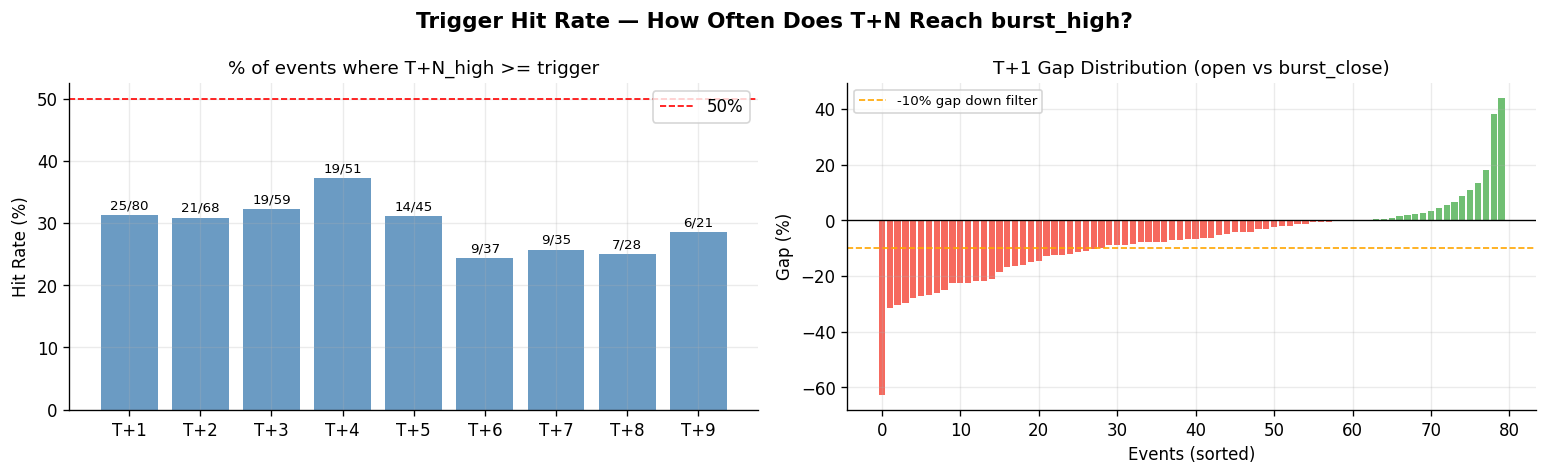


T+1 gap stats: mean=-7.4%, median=-6.6%
T+1 gap < -10%: 28 events (35%)


In [173]:
# ── Trigger Hit Rate Analysis ────────────────────────────────────────────────
# Critical question: how often does T+N price actually reach the burst_high trigger?
# If hit rate is low, most of v1's "returns" were phantom trades.

hit_rows = []
for t in range(1, 10):
    col = f'T{t}_triggered'
    data = events[col].dropna()
    n_total = len(data)
    n_hit   = data.sum()
    hit_rows.append({'T': f'T+{t}', 'n_total': n_total, 'n_hit': int(n_hit), 'hit_rate': n_hit/n_total})

hit_df = pd.DataFrame(hit_rows)
print('=== Trigger Hit Rate (T+N high >= burst_high) ===')
print(hit_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Trigger Hit Rate — How Often Does T+N Reach burst_high?', fontweight='bold')

ax = axes[0]
ax.bar(hit_df['T'], hit_df['hit_rate']*100, color='steelblue', alpha=0.8)
ax.axhline(50, color='red', linestyle='--', linewidth=1, label='50%')
ax.set_ylabel('Hit Rate (%)')
ax.set_title('% of events where T+N_high >= trigger')
ax.legend()
for i, row in hit_df.iterrows():
    ax.text(i, row['hit_rate']*100 + 1, f'{row["n_hit"]}/{row["n_total"]}', ha='center', fontsize=8)

ax = axes[1]
gap_data_t1 = events['T1_gap'].dropna()
colors = ['#4CAF50' if v >= 0 else '#F44336' for v in gap_data_t1]
ax.bar(range(len(gap_data_t1)), sorted(gap_data_t1), 
       color=['#4CAF50' if v >= 0 else '#F44336' for v in sorted(gap_data_t1)], alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(-10, color='orange', linestyle='--', linewidth=1, label='-10% gap down filter')
ax.set_title('T+1 Gap Distribution (open vs burst_close)')
ax.set_ylabel('Gap (%)')
ax.set_xlabel('Events (sorted)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'v2_fig02_trigger_hit.png', bbox_inches='tight')
plt.show()

print(f'\nT+1 gap stats: mean={gap_data_t1.mean():.1f}%, median={gap_data_t1.median():.1f}%')
print(f'T+1 gap < -10%: {(gap_data_t1 < -10).sum()} events ({(gap_data_t1 < -10).mean():.0%})')

## 4. Edge Analysis — Scenario A (Conditional Trigger) vs B (Open Entry)

This is the core correction from v1: we now measure returns **only on trades that would have actually executed**.

In [174]:
from scipy.stats import ttest_1samp

def fdr_correction(p_values, alpha=0.05):
    """Benjamini-Hochberg FDR correction. Returns array of booleans (rejected)."""
    n = len(p_values)
    sorted_idx = np.argsort(p_values)
    sorted_p   = np.array(p_values)[sorted_idx]
    thresholds = [(i+1)/n * alpha for i in range(n)]
    rejected   = sorted_p <= thresholds
    # Propagate: if k is rejected, all i < k are also rejected
    if rejected.any():
        last_rejected = np.where(rejected)[0][-1]
        rejected[:last_rejected+1] = True
    result = np.zeros(n, dtype=bool)
    result[sorted_idx] = rejected
    return result

# ── Summary for both scenarios ───────────────────────────────────────────────
summary_rows = []

for scenario, col_suffix in [('A: Conditional (trigger fill)', '_ret_trigger'),
                              ('B: Unconditional (open entry)',  '_ret_open')]:
    for t in range(1, 10):
        col  = f'T{t}{col_suffix}'
        data = events[col].dropna()
        if len(data) < 3:
            continue
        t_stat, p_val = ttest_1samp(data, 0)
        wr = (data > 0).mean()
        pf = data[data>0].sum() / abs(data[data<0].sum()) if data[data<0].sum() != 0 else np.inf
        summary_rows.append({
            'scenario': scenario,
            'T': f'T+{t}',
            'n': len(data),
            'mean': data.mean(),
            'median': data.median(),
            'std': data.std(),
            'win_rate': wr,
            'profit_factor': pf,
            'p_raw': p_val,
        })

summary = pd.DataFrame(summary_rows)

# Apply FDR correction separately per scenario
for scenario in summary['scenario'].unique():
    mask = summary['scenario'] == scenario
    p_vals = summary.loc[mask, 'p_raw'].values
    rejected = fdr_correction(p_vals)
    summary.loc[mask, 'sig_fdr'] = rejected
    summary.loc[mask, 'sig_label'] = ['✓ sig*' if r else '' for r in rejected]

pd.set_option('display.float_format', '{:.3f}'.format)
print('=== SCENARIO A: CONDITIONAL (trigger fill) ===')
scA = summary[summary['scenario'].str.startswith('A')]
print(scA[['T','n','mean','median','win_rate','profit_factor','p_raw','sig_label']].to_string(index=False))
print()
print('=== SCENARIO B: UNCONDITIONAL (open entry) ===')
scB = summary[summary['scenario'].str.startswith('B')]
print(scB[['T','n','mean','median','win_rate','profit_factor','p_raw','sig_label']].to_string(index=False))
print()
print('NOTE: sig_label uses FDR (Benjamini-Hochberg) correction across T+1..T+9 within each scenario.')

=== SCENARIO A: CONDITIONAL (trigger fill) ===
  T  n   mean  median  win_rate  profit_factor  p_raw sig_label
T+1 25  5.378  -2.398     0.440          1.758  0.321          
T+2 21  5.563   0.744     0.524          1.809  0.399          
T+3 19  0.039  -1.242     0.474          1.007  0.992          
T+4 19 11.086   0.855     0.526          3.627  0.255          
T+5 14 -2.264  -2.075     0.357          0.611  0.541          
T+6  9  3.761   0.000     0.444          2.190  0.418          
T+7  9 -3.778  -1.791     0.111          0.088  0.058          
T+8  7  0.791   0.495     0.714          2.574  0.384          
T+9  6 -1.031  -0.085     0.500          0.465  0.569          

=== SCENARIO B: UNCONDITIONAL (open entry) ===
  T  n   mean  median  win_rate  profit_factor  p_raw sig_label
T+1 80  5.372   0.476     0.512          2.037  0.038          
T+2 68 -0.817  -1.629     0.456          0.888  0.748          
T+3 59  3.097   0.495     0.542          1.746  0.154          
T+4 51  3

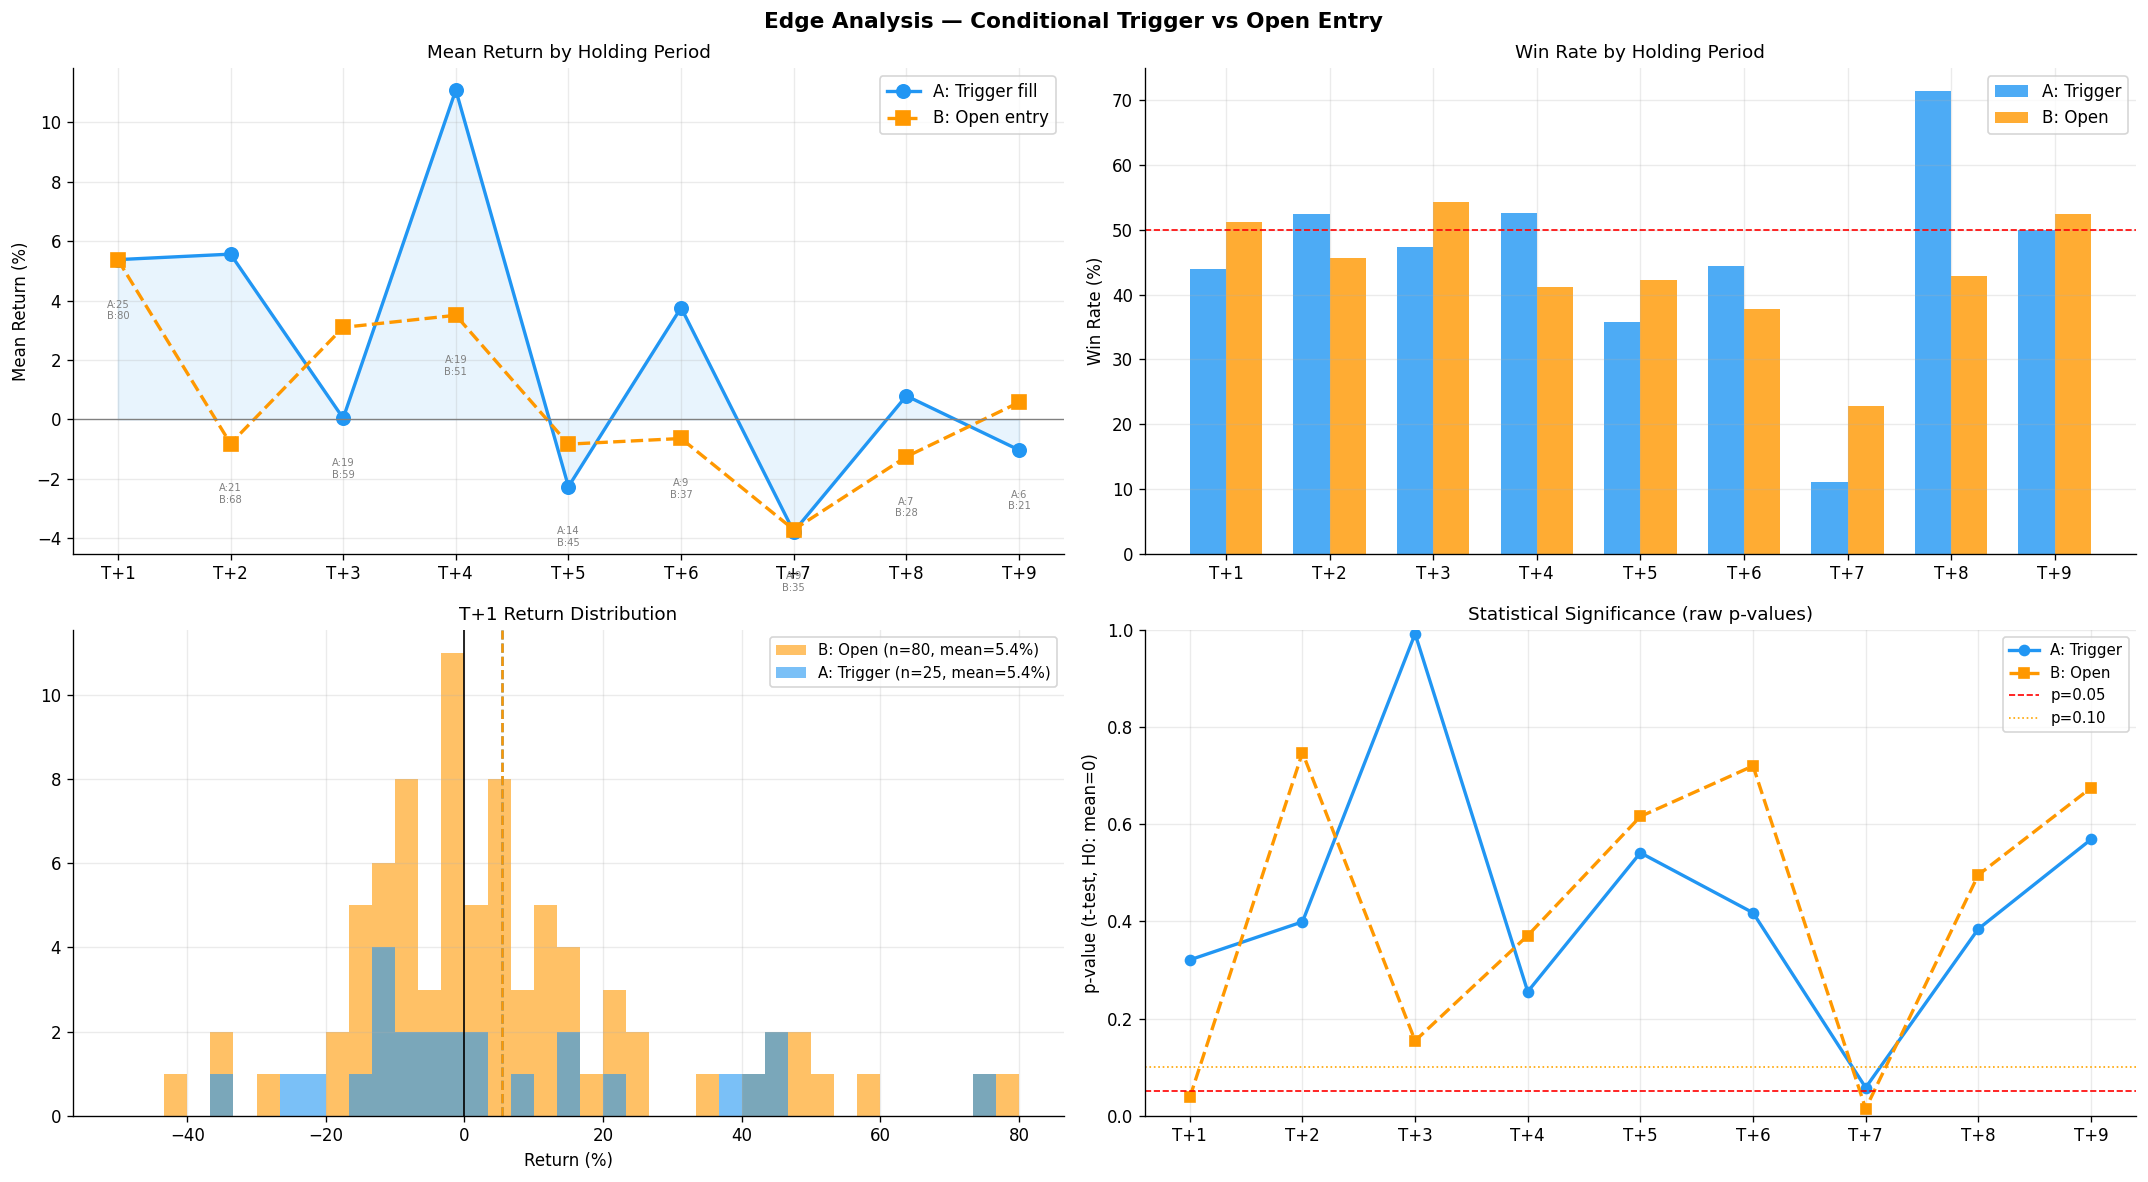

In [175]:
# ── Edge Visualization ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)
fig.suptitle('Edge Analysis — Conditional Trigger vs Open Entry', fontweight='bold')

# ── Top left: mean return by T and scenario ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
t_vals = range(1, 10)

means_A = [events[f'T{t}_ret_trigger'].dropna().mean() for t in t_vals]
means_B = [events[f'T{t}_ret_open'].dropna().mean()    for t in t_vals]
ns_A    = [len(events[f'T{t}_ret_trigger'].dropna()) for t in t_vals]
ns_B    = [len(events[f'T{t}_ret_open'].dropna())    for t in t_vals]

ax1.plot(list(t_vals), means_A, 'o-', color='#2196F3', linewidth=2, markersize=8, label='A: Trigger fill')
ax1.plot(list(t_vals), means_B, 's--', color='#FF9800', linewidth=2, markersize=8, label='B: Open entry')
ax1.axhline(0, color='gray', linewidth=0.8)
ax1.fill_between(list(t_vals), means_A, 0, alpha=0.1, color='#2196F3')
ax1.set_xticks(list(t_vals))
ax1.set_xticklabels([f'T+{t}' for t in t_vals])
ax1.set_ylabel('Mean Return (%)')
ax1.set_title('Mean Return by Holding Period')
ax1.legend()

# Annotate n counts
for t, nA, nB in zip(t_vals, ns_A, ns_B):
    ax1.text(t, min(means_A[t-1], means_B[t-1]) - 2, f'A:{nA}\nB:{nB}', 
             ha='center', fontsize=6, color='gray')

# ── Top right: win rate comparison ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
wr_A = [(events[f'T{t}_ret_trigger'].dropna() > 0).mean() for t in t_vals]
wr_B = [(events[f'T{t}_ret_open'].dropna() > 0).mean()    for t in t_vals]

x = np.array(list(t_vals))
width = 0.35
ax2.bar(x - width/2, [v*100 for v in wr_A], width, color='#2196F3', alpha=0.8, label='A: Trigger')
ax2.bar(x + width/2, [v*100 for v in wr_B], width, color='#FF9800', alpha=0.8, label='B: Open')
ax2.axhline(50, color='red', linestyle='--', linewidth=1)
ax2.set_xticks(list(t_vals))
ax2.set_xticklabels([f'T+{t}' for t in t_vals])
ax2.set_ylabel('Win Rate (%)')
ax2.set_title('Win Rate by Holding Period')
ax2.legend()

# ── Bottom left: T+1 return distributions ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
t1_A = events['T1_ret_trigger'].dropna()
t1_B = events['T1_ret_open'].dropna()
bins  = np.linspace(-50, 80, 40)
ax3.hist(t1_B.clip(-50, 80), bins=bins, alpha=0.6, color='#FF9800', label=f'B: Open (n={len(t1_B)}, mean={t1_B.mean():.1f}%)')
ax3.hist(t1_A.clip(-50, 80), bins=bins, alpha=0.6, color='#2196F3', label=f'A: Trigger (n={len(t1_A)}, mean={t1_A.mean():.1f}%)')
ax3.axvline(0, color='black', linewidth=1)
ax3.axvline(t1_A.mean(), color='#2196F3', linewidth=1.5, linestyle='--')
ax3.axvline(t1_B.mean(), color='#FF9800', linewidth=1.5, linestyle='--')
ax3.set_title('T+1 Return Distribution')
ax3.set_xlabel('Return (%)')
ax3.legend(fontsize=9)

# ── Bottom right: p-values with FDR threshold ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
pvals_A = [ttest_1samp(events[f'T{t}_ret_trigger'].dropna(), 0)[1] for t in t_vals]
pvals_B = [ttest_1samp(events[f'T{t}_ret_open'].dropna(), 0)[1]    for t in t_vals]

ax4.plot(list(t_vals), pvals_A, 'o-', color='#2196F3', linewidth=2, label='A: Trigger')
ax4.plot(list(t_vals), pvals_B, 's--', color='#FF9800', linewidth=2, label='B: Open')
ax4.axhline(0.05, color='red', linestyle='--', linewidth=1, label='p=0.05')
ax4.axhline(0.10, color='orange', linestyle=':', linewidth=1, label='p=0.10')
ax4.set_xticks(list(t_vals))
ax4.set_xticklabels([f'T+{t}' for t in t_vals])
ax4.set_ylabel('p-value (t-test, H0: mean=0)')
ax4.set_title('Statistical Significance (raw p-values)')
ax4.legend(fontsize=9)
ax4.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'v2_fig03_edge.png', bbox_inches='tight')
plt.show()

## 5. Filter Optimization — H3 (Candle Quality) + H4 (Persistence)

In [176]:
# ── Progressive Filter Analysis ──────────────────────────────────────────────
# Primary metric: T+1 unconditional open entry (most realistic for small-cap)
# Secondary: T+1 conditional trigger

def filter_stats(subset, t=1, scenario='open'):
    col = f'T{t}_ret_trigger' if scenario == 'trigger' else f'T{t}_ret_open'
    s = subset[col].dropna()
    if len(s) < 4:
        return None
    _, p = ttest_1samp(s, 0)
    pf = s[s>0].sum() / abs(s[s<0].sum()) if s[s<0].sum() != 0 else np.inf
    return {'n': len(s), 'mean': s.mean(), 'wr': (s>0).mean(), 'pf': pf, 'p': p}

ev = events.copy()
ev['gap_ok']         = ev['T1_gap'].isna() | (ev['T1_gap'] > -10)
ev['hi_ibkr']        = ev['ibkr_chg'] >= 30
ev['hi_persist']     = ev['presence_pct'] >= 0.60
ev['hi_rvol']        = ev['rvol'] >= 2.0
# Directional filters (NEW)
ev['above_trigger']  = ev['T1_open_above_trigger'].fillna(False).astype(bool)
ev['gap_mild']       = ev['T1_gap_vs_trigger'] >= -5   # < 5% below trigger
ev['gap_neutral']    = ev['T1_gap_vs_trigger'] >= -3   # < 3% below trigger
ev['gap_below_5']    = ev['T1_gap_vs_trigger'].between(-10, -5)  # deep gap segment

filter_defs = [
    ('── BASELINE ──────────────────────────────────', None),
    ('All events',                                     ev),
    ('Green candle',                                   ev[ev['candle_green'].astype(bool)]),
    ('Green + close_pos >= 0.7',                       ev[(ev['candle_green'].astype(bool)) & (ev['close_pos']>=0.70)]),
    ('Green + close_pos >= 0.7 + wick < 1x',          ev[(ev['candle_green'].astype(bool)) & (ev['close_pos']>=0.70) & (ev['upper_wick_ratio']<=1.0)]),
    ('Green + gap_ok (T1 not > -10% below close)',     ev[(ev['candle_green'].astype(bool)) & ev['gap_ok']]),
    ('Green + gap_ok + ibkr_chg >= 30%',               ev[(ev['candle_green'].astype(bool)) & ev['gap_ok'] & ev['hi_ibkr']]),
    ('Presence >= 60%',                                ev[ev['hi_persist']]),
    ('Presence >= 60% + Green',                        ev[ev['hi_persist'] & (ev['candle_green'].astype(bool))]),
    ('Presence >= 60% + Green + gap_ok',               ev[ev['hi_persist'] & (ev['candle_green'].astype(bool)) & ev['gap_ok']]),
    ('Green + gap_ok + presence>=60% + ibkr>=30%',     ev[(ev['candle_green'].astype(bool)) & ev['gap_ok'] & ev['hi_persist'] & ev['hi_ibkr']]),
    ('Best combo (green+gap+persist+wick<1x+ibkr30)',  ev[(ev['candle_green'].astype(bool)) & ev['gap_ok'] & ev['hi_persist'] & ev['hi_ibkr'] & (ev['upper_wick_ratio']<=1.0)]),
    ('── DIRECTIONAL (gap vs trigger) ─────────────', None),
    ('T+1 open above trigger (gap >= 0%)',             ev[ev['above_trigger']]),
    ('T+1 gap mild (>= -5% below trigger)',            ev[ev['gap_mild']]),
    ('T+1 gap neutral (>= -3% below trigger)',         ev[ev['gap_neutral']]),
    ('T+1 gap deep (-10% to -5% below trigger)',       ev[ev['gap_below_5']]),
    ('Green + above trigger',                          ev[ev['candle_green'].astype(bool) & ev['above_trigger']]),
    ('Green + gap mild (>= -5%)',                      ev[ev['candle_green'].astype(bool) & ev['gap_mild']]),
    ('Green + gap neutral (>= -3%)',                   ev[ev['candle_green'].astype(bool) & ev['gap_neutral']]),
    ('Green + above trigger + presence >= 60%',        ev[ev['candle_green'].astype(bool) & ev['above_trigger'] & ev['hi_persist']]),
    ('Green + gap mild + presence >= 60%',             ev[ev['candle_green'].astype(bool) & ev['gap_mild'] & ev['hi_persist']]),
]

print(f'{"Filter":55s}  {"n":>4}  {"WR_open":>7}  {"Mean_open":>10}  {"PF_open":>7}  {"p_open":>7}  {"WR_trig":>7}  {"Mean_trig":>10}  {"p_trig":>7}')
print('-'*130)

filter_results = []
for name, subset in filter_defs:
    if subset is None:
        print(f'\n{name}')
        continue
    so = filter_stats(subset, t=1, scenario='open')
    st = filter_stats(subset, t=1, scenario='trigger')
    if so is None:
        print(f'{name:55s}  {len(subset):>4}  (N insuficiente)')
        continue
    st_str = f'{st["wr"]:>7.0%}  {st["mean"]:>+10.1f}%  {st["p"]:>7.4f}' if st else '       —             —         —'
    print(f'{name:55s}  {so["n"]:>4}  {so["wr"]:>7.0%}  {so["mean"]:>+10.1f}%  {so["pf"]:>7.2f}  {so["p"]:>7.4f}  {st_str}')
    filter_results.append({'filter': name, 'n': so['n'], **{f'open_{k}': v for k,v in so.items()}})


Filter                                                      n  WR_open   Mean_open  PF_open   p_open  WR_trig   Mean_trig   p_trig
----------------------------------------------------------------------------------------------------------------------------------
All events                                                 80      51%        +5.4%     2.04   0.0378      44%        +5.4%   0.3208
Green candle                                               57      54%        +7.2%     2.43   0.0291      43%        +6.2%   0.3263
Green + close_pos >= 0.7                                   26      54%        +5.2%     1.98   0.2617      41%        +4.1%   0.5434
Green + close_pos >= 0.7 + wick < 1x                       26      54%        +5.2%     1.98   0.2617      41%        +4.1%   0.5434
Green + gap_ok                                             39      54%        +9.0%     2.97   0.0395      45%        +7.6%   0.2387
Green + gap_ok + ibkr_chg >= 30%                           37      51%   

2026-04-14 08:04:29,075 matplotlib.colorbar DEBUG locator: <matplotlib.ticker.AutoLocator object at 0x1758c7800>
2026-04-14 08:04:29,093 matplotlib.colorbar DEBUG locator: <matplotlib.ticker.AutoLocator object at 0x3131688f0>


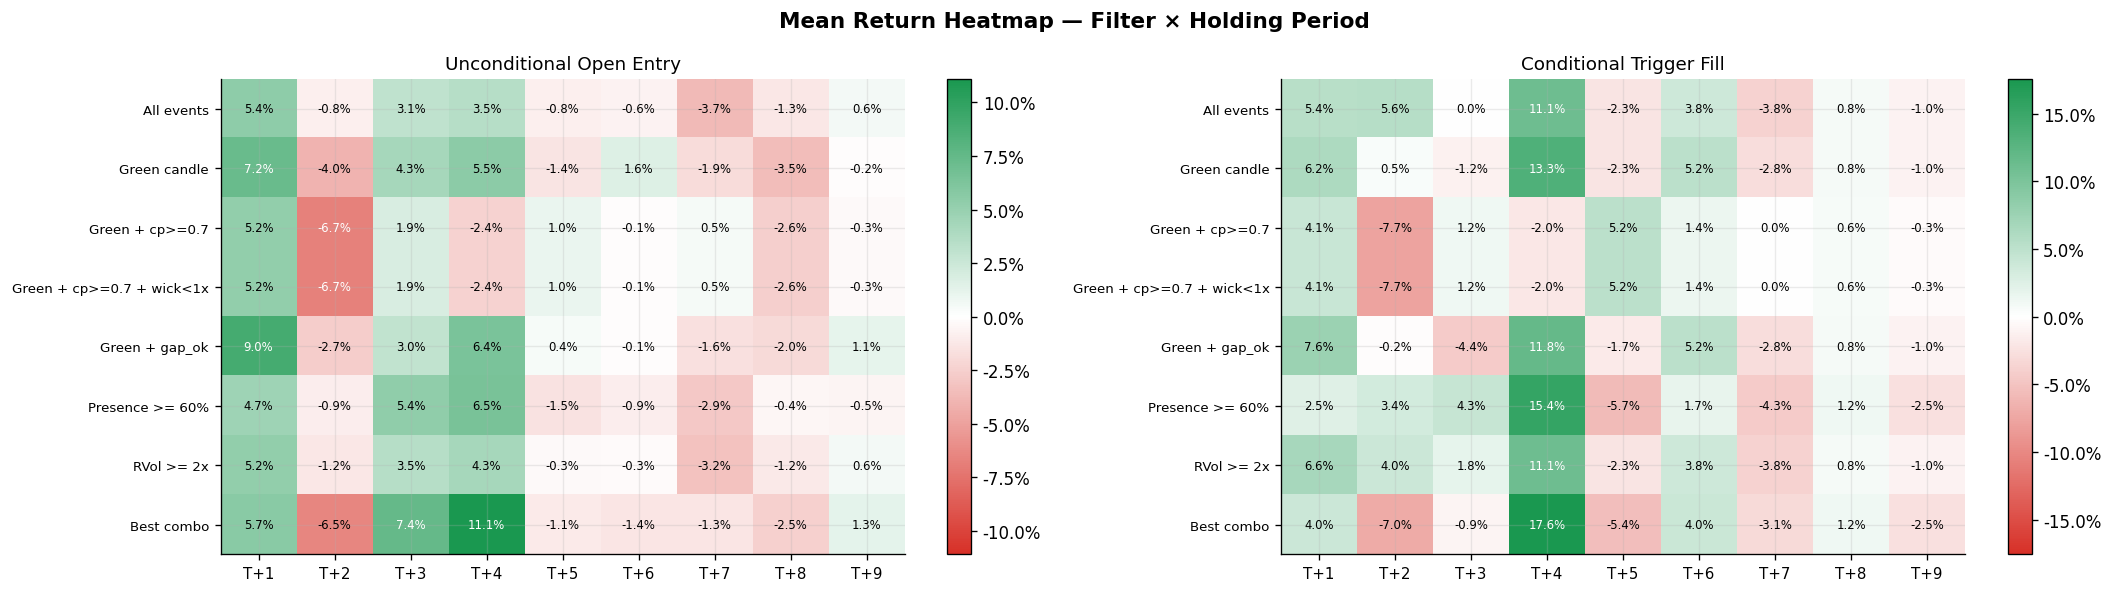

In [177]:
# ── Filter Heatmap: metric × holding period ──────────────────────────────────
# Show mean return for best filters across T+1..T+5

TOP_FILTERS = [
    ('All events',                ev),
    ('Green candle',              ev[ev['candle_green'].astype(bool)]),
    ('Green + cp>=0.7',           ev[(ev['candle_green'].astype(bool)) & (ev['close_pos']>=0.70)]),
    ('Green + cp>=0.7 + wick<1x', ev[(ev['candle_green'].astype(bool)) & (ev['close_pos']>=0.70) & (ev['upper_wick_ratio']<=1.0)]),
    ('Green + gap_ok',            ev[(ev['candle_green'].astype(bool)) & ev['gap_ok']]),
    ('Presence >= 60%',           ev[ev['hi_persist']]),
    ('RVol >= 2x',                ev[ev['hi_rvol']]),
    ('Best combo',                ev[(ev['candle_green'].astype(bool)) & ev['gap_ok'] & ev['hi_persist'] & ev['hi_ibkr']]),
]

mat_open    = np.full((len(TOP_FILTERS), 9), np.nan)
mat_trigger = np.full((len(TOP_FILTERS), 9), np.nan)
n_mat       = np.full((len(TOP_FILTERS), 9), 0)

for i, (name, subset) in enumerate(TOP_FILTERS):
    for t in range(1, 10):
        s_o = subset[f'T{t}_ret_open'].dropna()
        s_t = subset[f'T{t}_ret_trigger'].dropna()
        if len(s_o) >= 3:
            mat_open[i, t-1]    = s_o.mean()
            mat_trigger[i, t-1] = s_t.mean() if len(s_t) >= 3 else np.nan
            n_mat[i, t-1]       = len(s_o)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Mean Return Heatmap — Filter × Holding Period', fontweight='bold')

cmap = LinearSegmentedColormap.from_list('rwg', ['#d73027','white','#1a9850'])
filter_names = [f[0] for f in TOP_FILTERS]
t_labels = [f'T+{t}' for t in range(1,10)]

for ax, mat, title in [(axes[0], mat_open, 'Unconditional Open Entry'),
                        (axes[1], mat_trigger, 'Conditional Trigger Fill')]:
    vmax = np.nanmax(np.abs(mat)) if not np.all(np.isnan(mat)) else 1
    im = ax.imshow(mat, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(9))
    ax.set_xticklabels(t_labels, fontsize=9)
    ax.set_yticks(range(len(filter_names)))
    ax.set_yticklabels(filter_names, fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, format='%.1f%%')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.1f}%', ha='center', va='center', fontsize=7,
                        color='black' if abs(v) < vmax*0.6 else 'white')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'v2_fig04_filter_heatmap.png', bbox_inches='tight')
plt.show()

## 6. Risk Metrics & Position Sizing

In [178]:
# ── Risk metrics for key subsets ─────────────────────────────────────────────

def risk_metrics(ret_series, label='', capital=10000):
    s = ret_series.dropna() / 100  # to decimals
    if len(s) < 5:
        return {}
    
    wins  = s[s > 0]
    losses = s[s < 0]
    wr    = len(wins) / len(s)
    avg_w = wins.mean()  if len(wins)  > 0 else 0
    avg_l = losses.mean() if len(losses) > 0 else 0
    rr    = abs(avg_w / avg_l) if avg_l != 0 else np.inf
    
    sharpe = s.mean() / s.std() * np.sqrt(52) if s.std() > 0 else 0
    kelly  = wr - (1-wr)/rr if not np.isinf(rr) and rr > 0 else 0
    
    equity = capital * (1 + s).cumprod()
    dd     = (equity - equity.cummax()) / equity.cummax()
    max_dd = dd.min()
    
    var5  = s.quantile(0.05)
    cvar5 = s[s <= var5].mean()
    
    bs = bootstrap((s.values,), np.mean, n_resamples=2000, confidence_level=0.95)
    
    return {
        'label': label, 'n': len(s),
        'win_rate': wr, 'mean_ret': s.mean()*100, 'std': s.std()*100,
        'rr_ratio': rr, 'sharpe_ann': sharpe,
        'kelly_half': max(kelly/2, 0),
        'max_dd': max_dd*100,
        'cvar5': cvar5*100,
        'ci_lo': bs.confidence_interval.low*100,
        'ci_hi': bs.confidence_interval.high*100,
    }

risk_rows = []
for label, subset, scenario in [
    ('All / Open entry',           ev, 'ret_open'),
    ('All / Trigger fill',         ev, 'ret_trigger'),
    ('Green / Open',               ev[ev['candle_green'].astype(bool)], 'ret_open'),
    ('Green+cp>=0.7 / Open',       ev[(ev['candle_green'].astype(bool))&(ev['close_pos']>=0.70)], 'ret_open'),
    ('Green+gap_ok / Open',        ev[(ev['candle_green'].astype(bool))&ev['gap_ok']], 'ret_open'),
    ('Presence>=60% / Open',       ev[ev['hi_persist']], 'ret_open'),
    ('Best combo / Open',          ev[(ev['candle_green'].astype(bool))&ev['gap_ok']&ev['hi_persist']&ev['hi_ibkr']], 'ret_open'),
]:
    m = risk_metrics(subset[f'T1_{scenario}'], label=label)
    if m:
        risk_rows.append(m)

risk_df = pd.DataFrame(risk_rows)
print('=== Risk Metrics (T+1 returns) ===')
print(risk_df[['label','n','win_rate','mean_ret','rr_ratio','sharpe_ann','kelly_half','max_dd','cvar5','ci_lo','ci_hi']].round(3).to_string(index=False))

=== Risk Metrics (T+1 returns) ===
               label  n  win_rate  mean_ret  rr_ratio  sharpe_ann  kelly_half  max_dd   cvar5  ci_lo  ci_hi
    All / Open entry 80     0.512     5.372     1.938       1.703       0.130 -76.700 -34.860  0.507 10.398
  All / Trigger fill 25     0.440     5.378     2.237       1.462       0.095 -54.114 -29.733 -3.156 17.014
        Green / Open 57     0.544     7.215     2.036       2.139       0.160 -59.490 -34.279  1.505 13.708
Green+cp>=0.7 / Open 26     0.538     5.243     1.700       1.624       0.133 -45.597 -25.644 -2.143 15.922
 Green+gap_ok / Open 39     0.538     8.997     2.544       2.462       0.179 -58.331 -38.064  1.950 18.156
Presence>=60% / Open 52     0.538     4.664     1.564       1.512       0.122 -71.776 -37.577 -1.383 10.941
   Best combo / Open 22     0.545     5.665     1.655       1.638       0.135 -57.609 -38.064 -3.088 16.931


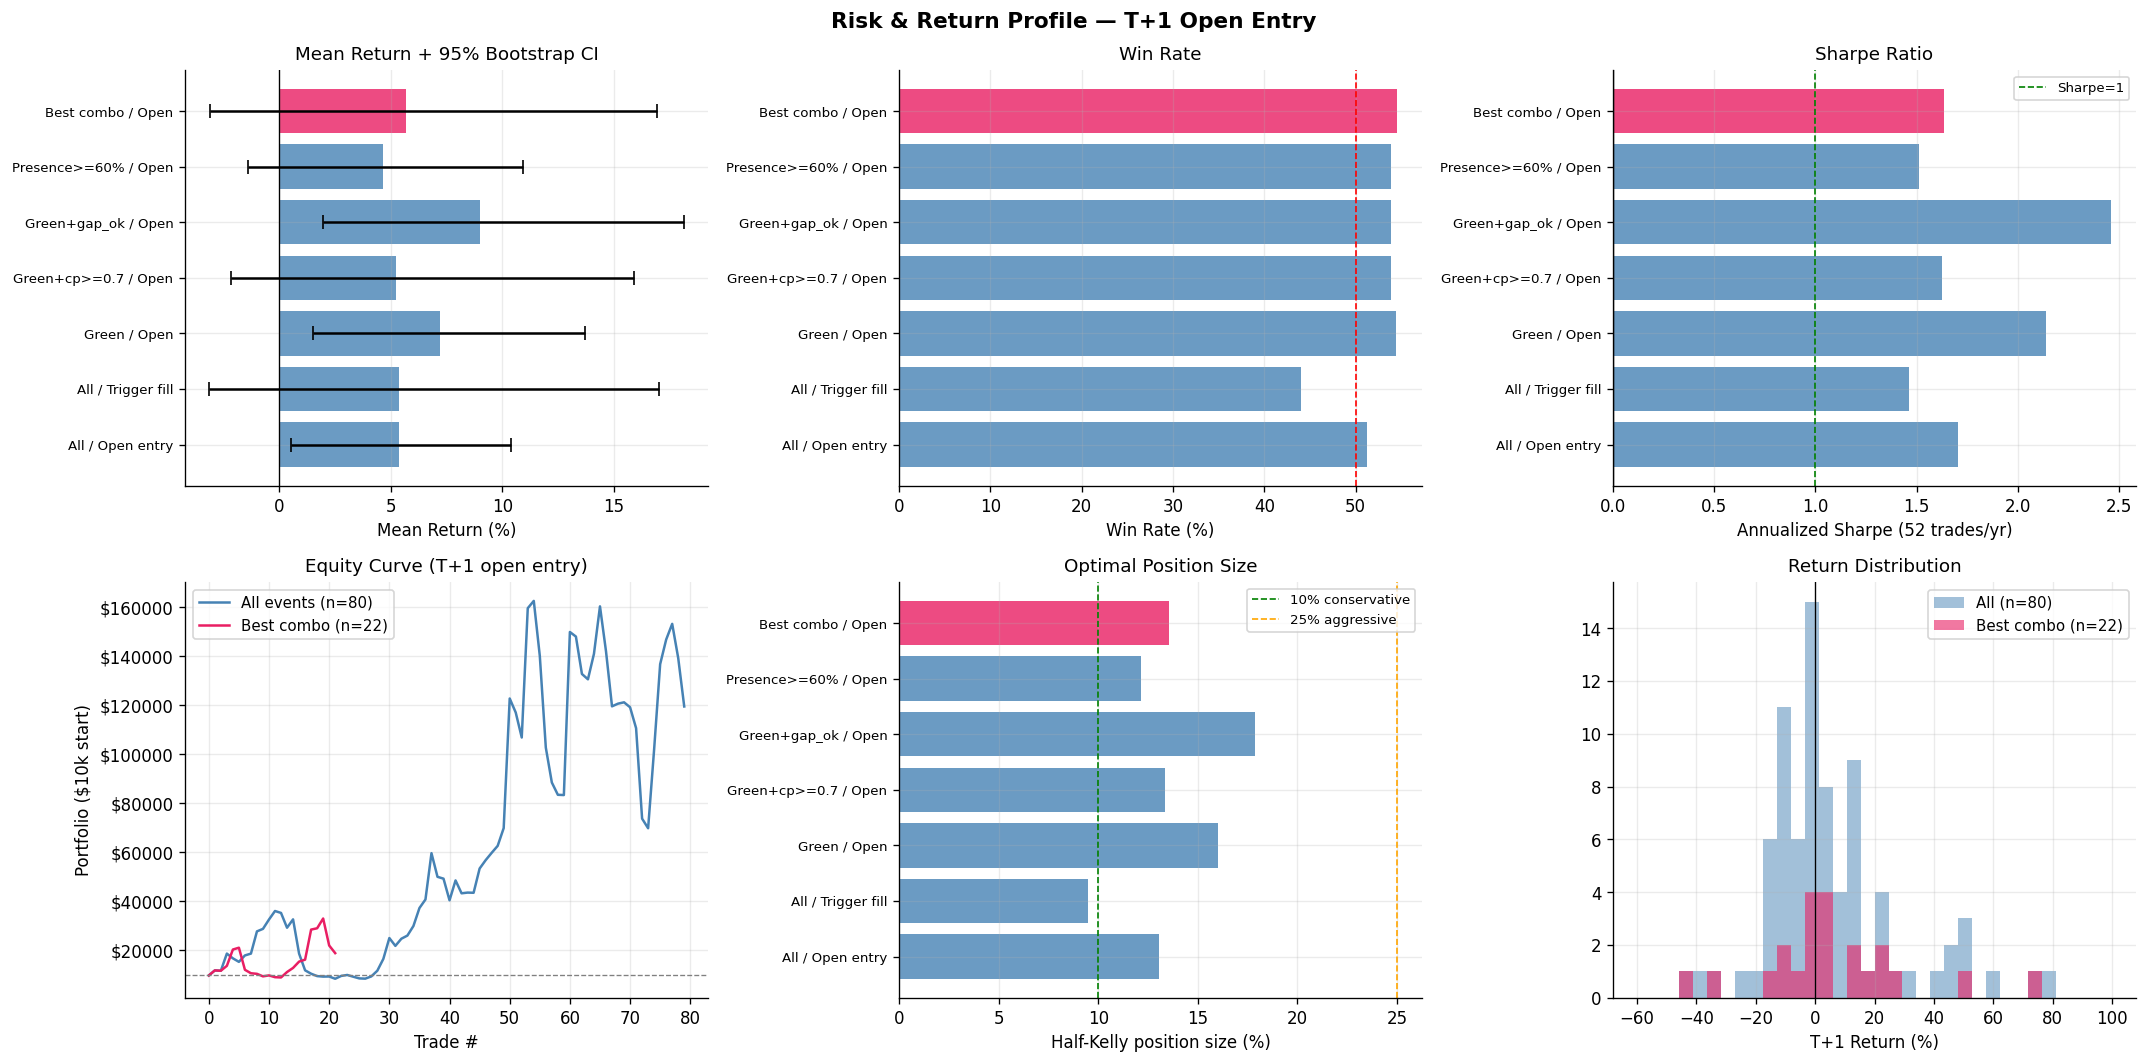

In [179]:
# ── Risk Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Risk & Return Profile — T+1 Open Entry', fontweight='bold')

labels = risk_df['label'].values
y_pos  = range(len(labels))
colors = ['steelblue']*len(labels)
if len(colors) > 0: colors[-1] = '#E91E63'  # highlight best combo

# Mean return + CI
ax = axes[0][0]
ax.barh(list(y_pos), risk_df['mean_ret'], color=colors, alpha=0.8)
ax.errorbar(risk_df['mean_ret'], list(y_pos),
            xerr=[abs(risk_df['mean_ret']-risk_df['ci_lo']),
                  abs(risk_df['ci_hi']-risk_df['mean_ret'])],
            fmt='none', color='black', capsize=4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(list(y_pos)); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Mean Return (%)')
ax.set_title('Mean Return + 95% Bootstrap CI')

# Win rate
ax = axes[0][1]
ax.barh(list(y_pos), risk_df['win_rate']*100, color=colors, alpha=0.8)
ax.axvline(50, color='red', linestyle='--', linewidth=1)
ax.set_yticks(list(y_pos)); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Win Rate (%)')
ax.set_title('Win Rate')

# Sharpe
ax = axes[0][2]
ax.barh(list(y_pos), risk_df['sharpe_ann'].clip(-3, 5), color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(1, color='green', linestyle='--', linewidth=1, label='Sharpe=1')
ax.set_yticks(list(y_pos)); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Annualized Sharpe (52 trades/yr)')
ax.set_title('Sharpe Ratio')
ax.legend(fontsize=8)

# Equity curve: best filter
ax = axes[1][0]
best_s = ev[(ev['candle_green'].astype(bool)) & ev['gap_ok'] & ev['hi_persist'] & ev['hi_ibkr']]['T1_ret_open'].dropna() / 100
all_s  = ev['T1_ret_open'].dropna() / 100
for s, lbl, col in [(all_s, 'All events', 'steelblue'), (best_s, 'Best combo', '#E91E63')]:
    eq = 10000 * (1+s).cumprod()
    ax.plot(eq.reset_index(drop=True).values, label=f'{lbl} (n={len(s)})', linewidth=1.5, color=col)
ax.axhline(10000, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Portfolio ($10k start)')
ax.set_xlabel('Trade #')
ax.set_title('Equity Curve (T+1 open entry)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))

# Kelly sizing
ax = axes[1][1]
ax.barh(list(y_pos), risk_df['kelly_half'].clip(0, 0.5)*100, color=colors, alpha=0.8)
ax.axvline(10, color='green', linestyle='--', linewidth=1, label='10% conservative')
ax.axvline(25, color='orange', linestyle='--', linewidth=1, label='25% aggressive')
ax.set_yticks(list(y_pos)); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Half-Kelly position size (%)')
ax.set_title('Optimal Position Size')
ax.legend(fontsize=8)

# T+1 return distribution best vs all
ax = axes[1][2]
bins = np.linspace(-60, 100, 35)
ax.hist(all_s*100, bins=bins, alpha=0.5, color='steelblue', label=f'All (n={len(all_s)})')
ax.hist(best_s*100, bins=bins, alpha=0.6, color='#E91E63', label=f'Best combo (n={len(best_s)})')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('T+1 Return (%)')
ax.set_title('Return Distribution')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'v2_fig05_risk.png', bbox_inches='tight')
plt.show()

## 7. System vs Finviz Overlap — What Did the System Miss?

In [180]:
# ── Load system trades & candidates ──────────────────────────────────────────
conn2 = sqlite3.connect(DB_TS)

pc = pd.read_sql("""
    SELECT symbol, detection_date, pattern_type, status
    FROM proactive_candidates
    WHERE detection_date >= '2026-03-24'
""", conn2)

trades_raw = pd.read_sql("""
    SELECT event_type, symbol, payload, timestamp
    FROM events_log
    WHERE event_type IN ('TRADE_OPENED','TRADE_CLOSED')
      AND timestamp >= '2026-03-24'
    ORDER BY timestamp
""", conn2)
conn2.close()

pc['detection_date'] = pd.to_datetime(pc['detection_date']).dt.date

# Parse trade payloads
trade_rows = []
for _, row in trades_raw.iterrows():
    p = json.loads(row['payload'])
    trade_rows.append({
        'type':     row['event_type'],
        'ts':       pd.Timestamp(row['timestamp']),
        'symbol':   row['symbol'] or p.get('symbol',''),
        'strategy': p.get('strategy',''),
        'pnl':      p.get('pnl', np.nan),
        'entry':    p.get('entry_price', p.get('fill_price', np.nan)),
        'exit':     p.get('exit_price', np.nan),
    })

trades = pd.DataFrame(trade_rows)
trades['date'] = trades['ts'].dt.date

# Closed trades with PBT1
pbt1_closed = trades[(trades['type']=='TRADE_CLOSED') & (trades['strategy']=='PostBurstT1Strategy')]
print(f'Proactive candidates since 2026-03-24: {len(pc)}')
print(f'  Pattern types: {pc["pattern_type"].value_counts().to_dict()}')
print(f'\nClosed PBT1 trades: {len(pbt1_closed)}')
print(f'Closed trades (all strategies): {len(trades[trades["type"]=="TRADE_CLOSED"])}')

Proactive candidates since 2026-03-24: 139
  Pattern types: {'FINVIZ_TOP_GAINER': 99, 'POST_BURST_T1': 27, 'CATALYST_NEWS': 11, 'FIRST_RED_DAY': 2}

Closed PBT1 trades: 32
Closed trades (all strategies): 98


In [181]:
# ── Overlap analysis ──────────────────────────────────────────────────────────

cross = []
for _, b in burst.iterrows():
    ticker    = b['ticker']
    burst_dt  = pd.Timestamp(b['burst_date']).date()
    t1_dt     = get_trading_day(burst_dt, 1)
    
    # Was this ticker in proactive_candidates on T+1?
    detected = pc[
        (pc['symbol'] == ticker) &
        (pc['detection_date'] == burst_dt)  # nightly scan saves on burst day for T+1 entry
    ]
    
    # Did system actually enter a trade on T+1?
    traded_t1 = trades[
        (trades['symbol'] == ticker) &
        (trades['type'] == 'TRADE_OPENED') &
        (trades['date'] == t1_dt)
    ] if t1_dt else pd.DataFrame()
    
    # T+1 open entry return from events
    ev_row = events[events['ticker'] == ticker]
    ev_row = ev_row[ev_row['burst_date'] == burst_dt] if not ev_row.empty else pd.DataFrame()
    t1_ret = float(ev_row['T1_ret_open'].values[0]) if not ev_row.empty and not pd.isna(ev_row['T1_ret_open'].values[0]) else np.nan
    
    cross.append({
        'burst_date':      burst_dt,
        'ticker':          ticker,
        'n_snaps':         b['n_snaps'],
        'presence_pct':    b['presence_pct'],
        'fv_chg':          b['fv_chg_mean'],
        'candle_green':    ev_row['candle_green'].values[0] if not ev_row.empty else None,
        't1_ret_open':     t1_ret,
        'in_candidates':   len(detected) > 0,
        'candidate_status': detected['status'].values[0] if len(detected) > 0 else 'MISSED',
        'system_traded':   len(traded_t1) > 0,
    })

cross_df = pd.DataFrame(cross)

n_total   = len(cross_df)
n_cand    = cross_df['in_candidates'].sum()
n_entered = cross_df[cross_df['candidate_status'].isin(['ENTERED','TRADED'])].shape[0]
n_missed  = n_total - n_cand

print('=== SYSTEM vs FINVIZ BURST OVERLAP ===')
print(f'Total Finviz burst events:          {n_total}')
print(f'In proactive_candidates:            {n_cand} ({n_cand/n_total:.0%})')
print(f'  → ENTERED/TRADED:                 {n_entered}')
print(f'  → Other status:                   {n_cand - n_entered}')
print(f'MISSED completely:                  {n_missed} ({n_missed/n_total:.0%})')
print()

# Return of missed vs detected
missed_rets   = cross_df[~cross_df['in_candidates']]['t1_ret_open'].dropna()
detected_rets = cross_df[cross_df['in_candidates']]['t1_ret_open'].dropna()
if len(missed_rets) >= 3 and len(detected_rets) >= 3:
    from scipy.stats import mannwhitneyu
    u, p_mwu = mannwhitneyu(missed_rets, detected_rets, alternative='two-sided')
    print(f'T+1 open return — Missed: mean={missed_rets.mean():.1f}% (n={len(missed_rets)})')
    print(f'T+1 open return — Detected: mean={detected_rets.mean():.1f}% (n={len(detected_rets)})')
    print(f'Mann-Whitney p (same distribution): {p_mwu:.4f}')
    print('→ Were the MISSED events meaningfully different in return?')

=== SYSTEM vs FINVIZ BURST OVERLAP ===
Total Finviz burst events:          95
In proactive_candidates:            71 (75%)
  → ENTERED/TRADED:                 0
  → Other status:                   71
MISSED completely:                  24 (25%)

T+1 open return — Missed: mean=9.4% (n=19)
T+1 open return — Detected: mean=4.1% (n=61)
Mann-Whitney p (same distribution): 0.7345
→ Were the MISSED events meaningfully different in return?


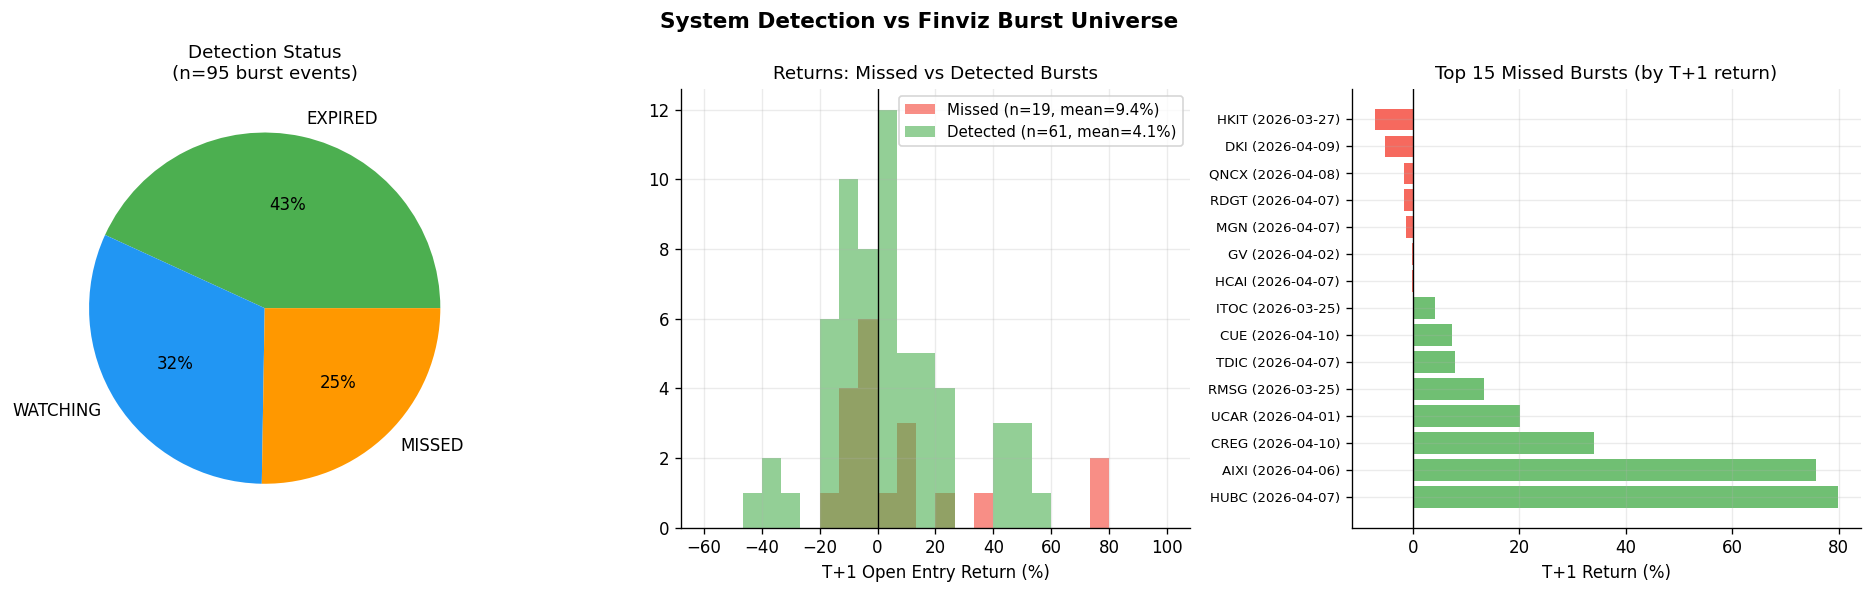

In [182]:
# ── Overlap Visualization ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('System Detection vs Finviz Burst Universe', fontweight='bold')

# Detection status pie
ax = axes[0]
status_counts = cross_df['candidate_status'].value_counts()
ax.pie(status_counts.values, labels=status_counts.index, autopct='%1.0f%%',
       colors=['#4CAF50','#2196F3','#FF9800','#F44336','#9E9E9E'][:len(status_counts)])
ax.set_title(f'Detection Status\n(n={len(cross_df)} burst events)')

# T+1 return: missed vs detected
ax = axes[1]
bins = np.linspace(-60, 100, 25)
if len(missed_rets) >= 3:
    ax.hist(missed_rets.clip(-60, 100), bins=bins, alpha=0.6, color='#F44336', label=f'Missed (n={len(missed_rets)}, mean={missed_rets.mean():.1f}%)')
if len(detected_rets) >= 3:
    ax.hist(detected_rets.clip(-60, 100), bins=bins, alpha=0.6, color='#4CAF50', label=f'Detected (n={len(detected_rets)}, mean={detected_rets.mean():.1f}%)')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('T+1 Open Entry Return (%)')
ax.set_title('Returns: Missed vs Detected Bursts')
ax.legend(fontsize=9)

# Top missed opportunities
ax = axes[2]
top_missed = cross_df[~cross_df['in_candidates']].nlargest(15, 't1_ret_open')
if not top_missed.empty:
    colors_bar = ['#4CAF50' if v >= 0 else '#F44336' for v in top_missed['t1_ret_open']]
    bars = ax.barh(range(len(top_missed)), top_missed['t1_ret_open'], color=colors_bar, alpha=0.8)
    ax.set_yticks(range(len(top_missed)))
    ax.set_yticklabels([f'{r["ticker"]} ({r["burst_date"]})' for _, r in top_missed.iterrows()], fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('T+1 Return (%)')
    ax.set_title('Top 15 Missed Bursts (by T+1 return)')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'v2_fig06_overlap.png', bbox_inches='tight')
plt.show()

## 8. Post-Burst Trajectory — Dump & Bounce Analysis

### Corrected methodology for Bounce Day detection

**v1 problem**: The "bottom" was identified in retrospect — you need to know all future prices to find the minimum.  
**v2 fix**: Bounce day is defined using **only information available at market close** of each day:

> A bounce day signal fires at close of day T when:
> 1. Cumulative return from trigger is ≤ -15% (ticker is in dump phase)
> 2. Today's candle: body_pct > 0 (green day) AND close_pos > 0.55 (closed in upper half)
> 3. The prior day was NOT also a bounce signal (avoid re-fires)

Forward return = next day open entry, hold to close.

Trajectory rows: 424 (70 tickers)


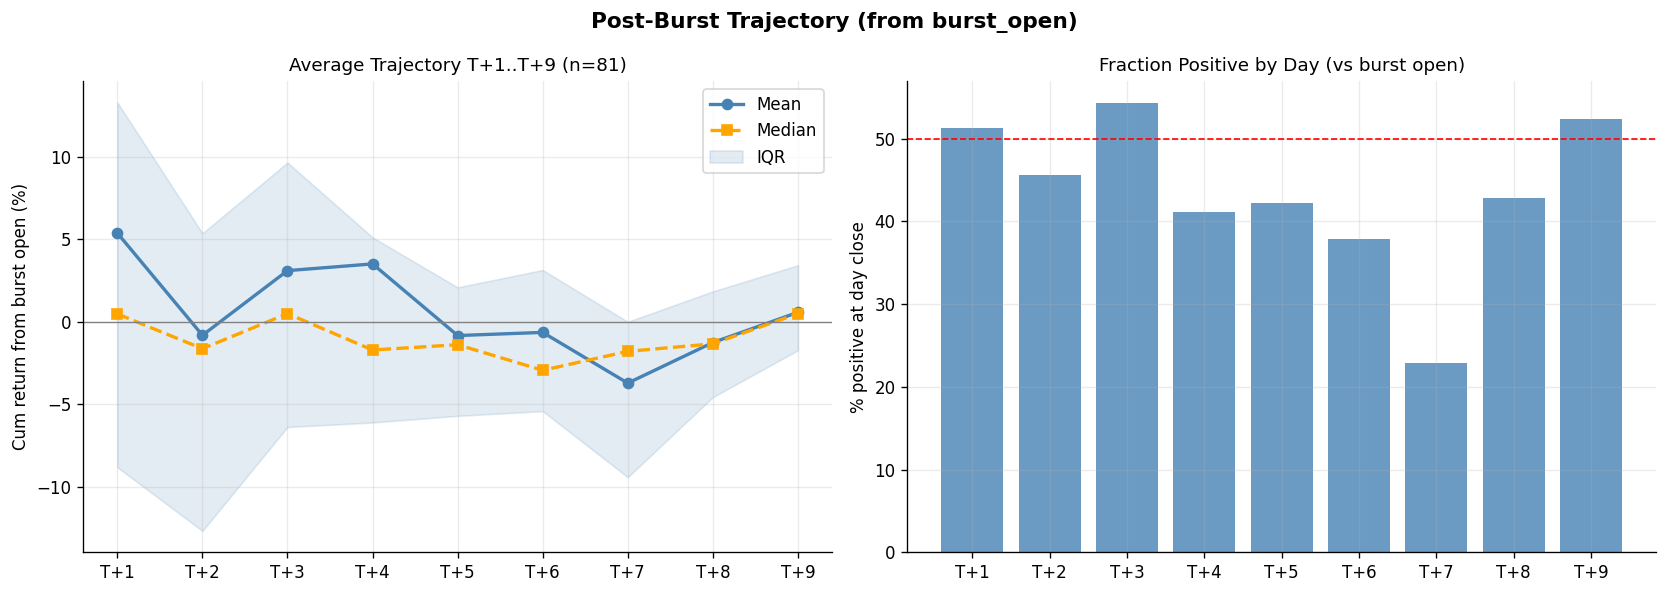

In [183]:
# ── Build day-by-day trajectory ───────────────────────────────────────────────
traj_rows = []

for _, ev_row in events.iterrows():
    ticker     = ev_row['ticker']
    burst_date = ev_row['burst_date']
    trigger    = ev_row['trigger']
    
    prev_close = ev_row['burst_close']
    
    for t in range(1, 10):
        o = ev_row.get(f'T{t}_open')
        h = ev_row.get(f'T{t}_high')
        l = ev_row.get(f'T{t}_low')
        c = ev_row.get(f'T{t}_close')
        cum_ret = ev_row.get(f'T{t}_ret_open')  # vs burst close open
        
        if any(v is None or (isinstance(v, float) and np.isnan(v)) for v in [o, c]):
            prev_close = None
            continue
        
        day_ret = (c / prev_close - 1) * 100 if prev_close and prev_close > 0 else np.nan
        rng     = (h - l) if h and l and h > l else np.nan
        cp      = (c - l) / rng if rng and not np.isnan(rng) else np.nan
        body    = (c - o) / o * 100 if o > 0 else np.nan
        
        # cum_ret_from_trigger (for dump threshold)
        cum_from_trigger = (c - trigger) / trigger * 100 if trigger and trigger > 0 else np.nan
        
        traj_rows.append({
            'ticker': ticker, 'burst_date': burst_date, 't': t,
            'open': o, 'close': c, 'high': h, 'low': l,
            'day_ret': day_ret,
            'cum_ret_vs_burst_open': cum_ret,
            'cum_ret_vs_trigger': cum_from_trigger,
            'close_pos': cp, 'body_pct': body,
        })
        prev_close = c

traj = pd.DataFrame(traj_rows)
print(f'Trajectory rows: {len(traj)} ({traj["ticker"].nunique()} tickers)')

# ── Average trajectory profile ────────────────────────────────────────────────
traj_mean   = traj.groupby('t')['cum_ret_vs_burst_open'].agg(['mean','median','std'])
traj_q25    = traj.groupby('t')['cum_ret_vs_burst_open'].quantile(0.25)
traj_q75    = traj.groupby('t')['cum_ret_vs_burst_open'].quantile(0.75)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Post-Burst Trajectory (from burst_open)', fontweight='bold')

ax = axes[0]
t_x = traj_mean.index
ax.plot(t_x, traj_mean['mean'],   'o-', color='steelblue', linewidth=2, label='Mean')
ax.plot(t_x, traj_mean['median'], 's--', color='orange', linewidth=2, label='Median')
ax.fill_between(t_x, traj_q25, traj_q75, alpha=0.15, color='steelblue', label='IQR')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(list(t_x))
ax.set_xticklabels([f'T+{t}' for t in t_x])
ax.set_ylabel('Cum return from burst open (%)')
ax.set_title(f'Average Trajectory T+1..T+9 (n={events["ticker"].nunique()})')
ax.legend()

# Win rate by day
ax = axes[1]
wr_by_t = traj.groupby('t').apply(lambda g: (g['cum_ret_vs_burst_open'] > 0).mean())
ax.bar(list(wr_by_t.index), wr_by_t.values*100, color='steelblue', alpha=0.8)
ax.axhline(50, color='red', linestyle='--', linewidth=1)
ax.set_xticks(list(wr_by_t.index))
ax.set_xticklabels([f'T+{t}' for t in wr_by_t.index])
ax.set_ylabel('% positive at day close')
ax.set_title('Fraction Positive by Day (vs burst open)')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'v2_fig07_trajectory.png', bbox_inches='tight')
plt.show()

In [184]:
# ── Bounce Day Detection (Prospective) ──────────────────────────────────────
DUMP_THRESHOLD   = -15.0  # cum_ret_vs_trigger <= -15% → in dump zone
BOUNCE_BODY_MIN  = 1.0    # green day body ≥ 1%
BOUNCE_CP_MIN    = 0.55   # close in upper 45% of range

bounce_signals = []

for (ticker, burst_date), grp in traj.groupby(['ticker','burst_date']):
    grp = grp.sort_values('t').reset_index(drop=True)
    prev_was_signal = False
    
    for idx, row in grp.iterrows():
        cum   = row['cum_ret_vs_trigger']
        body  = row['body_pct']
        cp    = row['close_pos']
        t_val = row['t']
        
        in_dump = not pd.isna(cum) and cum <= DUMP_THRESHOLD
        is_bounce_candle = (
            not pd.isna(body) and body >= BOUNCE_BODY_MIN and
            not pd.isna(cp) and cp >= BOUNCE_CP_MIN
        )
        
        is_signal = in_dump and is_bounce_candle and not prev_was_signal
        
        if is_signal:
            # Forward return: NEXT day open → close
            next_rows = grp[grp['t'] == t_val + 1]
            if not next_rows.empty:
                next_row = next_rows.iloc[0]
                fwd_ret = (next_row['close'] - next_row['open']) / next_row['open'] * 100 if next_row['open'] > 0 else np.nan
            else:
                fwd_ret = np.nan
            
            bounce_signals.append({
                'ticker':    ticker,
                'burst_date': burst_date,
                'signal_t':  t_val,
                'cum_at_signal': cum,
                'body_pct':  body,
                'close_pos': cp,
                'fwd_ret':   fwd_ret,
            })
        
        prev_was_signal = is_signal

bounce_df = pd.DataFrame(bounce_signals)
print(f'Bounce signals detected (prospective): {len(bounce_df)}')
print(f'Signals with forward return available: {bounce_df["fwd_ret"].notna().sum()}')

if len(bounce_df) >= 5:
    fwd = bounce_df['fwd_ret'].dropna()
    wr  = (fwd > 0).mean()
    _, p_t = ttest_1samp(fwd, 0)
    from scipy.stats import binomtest
    binom = binomtest((fwd>0).sum(), len(fwd), 0.5, alternative='greater')
    print(f'\nBounce signal edge:')
    print(f'  Win rate:          {wr:.1%}')
    print(f'  Mean fwd return:   {fwd.mean():.2f}%')
    print(f'  Median fwd return: {fwd.median():.2f}%')
    print(f'  t-test p (mean>0): {p_t:.4f}')
    print(f'  Binomial p (WR>50%): {binom.pvalue:.4f}')
    print(f'  Signal on T day:  {bounce_df["signal_t"].value_counts().sort_index().to_dict()}')
else:
    print('Not enough bounce signals for statistical test')

Bounce signals detected (prospective): 51
Signals with forward return available: 35

Bounce signal edge:
  Win rate:          40.0%
  Mean fwd return:   -1.82%
  Median fwd return: -0.96%
  t-test p (mean>0): 0.4248
  Binomial p (WR>50%): 0.9123
  Signal on T day:  {1: 11, 2: 8, 3: 5, 4: 3, 5: 7, 6: 5, 7: 3, 8: 3, 9: 6}


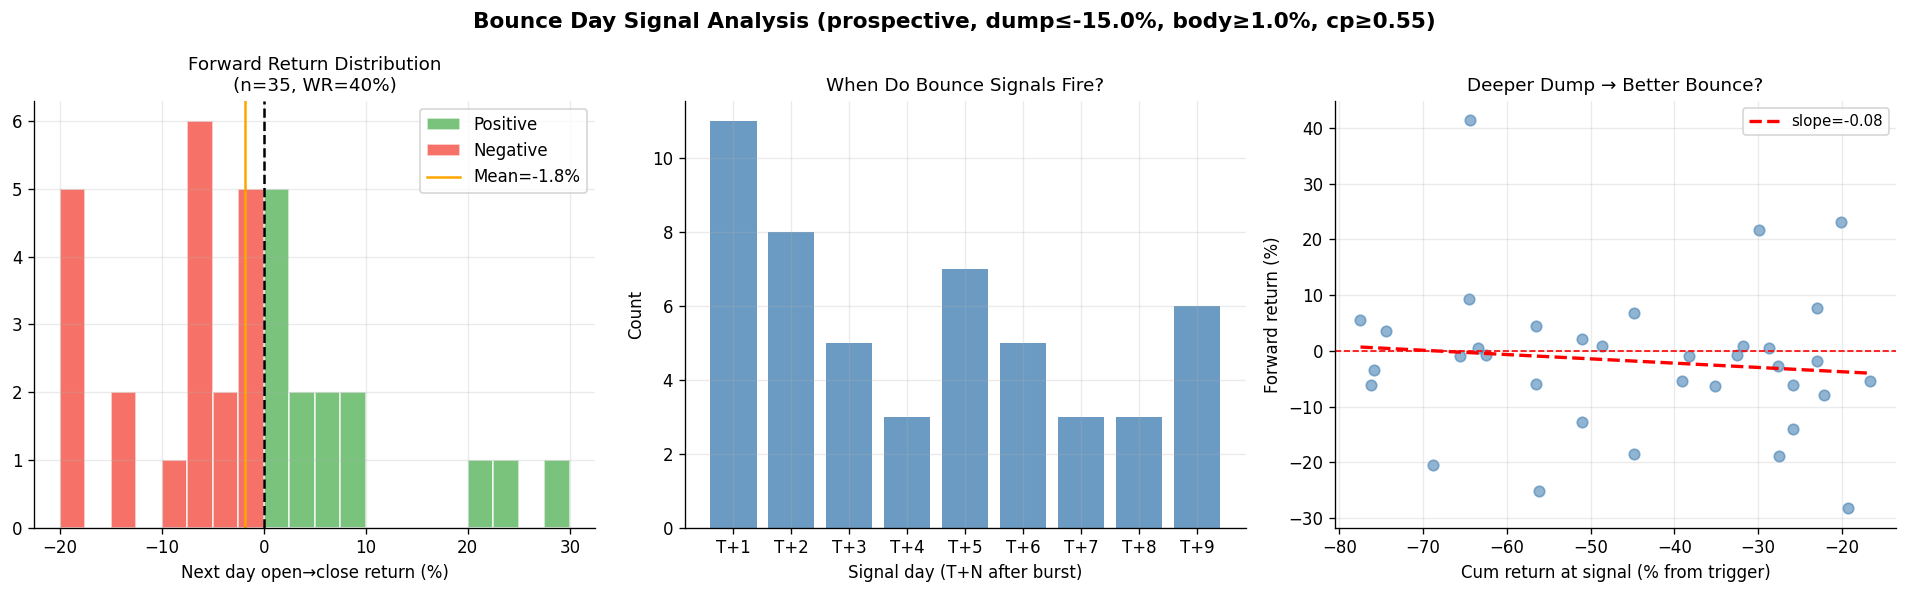

In [185]:
# ── Bounce Day Visualization ─────────────────────────────────────────────────
if 'bounce_df' not in dir():
    raise RuntimeError('bounce_df not defined — run cells in order (Section 8)')

fwd = bounce_df['fwd_ret'].dropna()

if len(fwd) < 5:
    print(f'Not enough data for visualization (n={len(fwd)})')
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Bounce Day Signal Analysis (prospective, dump≤{DUMP_THRESHOLD}%, body≥{BOUNCE_BODY_MIN}%, cp≥{BOUNCE_CP_MIN})',
                 fontweight='bold')

    ax = axes[0]
    bins = np.linspace(-20, 30, 21)
    ax.hist(fwd[fwd >= 0].clip(-20, 30), bins=bins, color='#4CAF50', alpha=0.75, edgecolor='white', label='Positive')
    ax.hist(fwd[fwd <  0].clip(-20, 30), bins=bins, color='#F44336', alpha=0.75, edgecolor='white', label='Negative')
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.axvline(fwd.mean(), color='orange', linewidth=1.5, label=f'Mean={fwd.mean():.1f}%')
    ax.set_title(f'Forward Return Distribution\n(n={len(fwd)}, WR={((fwd>0).mean()):.0%})')
    ax.set_xlabel('Next day open→close return (%)')
    ax.legend()

    ax = axes[1]
    signal_days = bounce_df['signal_t'].value_counts().sort_index()
    ax.bar([f'T+{t}' for t in signal_days.index], signal_days.values, color='steelblue', alpha=0.8)
    ax.set_xlabel('Signal day (T+N after burst)')
    ax.set_ylabel('Count')
    ax.set_title('When Do Bounce Signals Fire?')

    ax = axes[2]
    ax.scatter(bounce_df['cum_at_signal'], bounce_df['fwd_ret'].clip(-30, 50),
               alpha=0.6, s=40, color='steelblue')
    ax.axhline(0, color='red', linewidth=1, linestyle='--')
    valid_bounce = bounce_df.dropna(subset=['cum_at_signal', 'fwd_ret'])
    if len(valid_bounce) >= 5:
        z = np.polyfit(valid_bounce['cum_at_signal'], valid_bounce['fwd_ret'], 1)
        p_trend = np.poly1d(z)
        x_range = np.linspace(valid_bounce['cum_at_signal'].min(), valid_bounce['cum_at_signal'].max(), 50)
        ax.plot(x_range, p_trend(x_range), 'r--', linewidth=2, label=f'slope={z[0]:.2f}')
    ax.set_xlabel('Cum return at signal (% from trigger)')
    ax.set_ylabel('Forward return (%)')
    ax.set_title('Deeper Dump → Better Bounce?')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(ANALYSIS_DIR / 'v2_fig08_bounce.png', bbox_inches='tight')
    plt.show()


## 9. Per-Ticker Heatmap

2026-04-14 08:04:32,650 matplotlib.colorbar DEBUG locator: <matplotlib.ticker.AutoLocator object at 0x1757d4470>


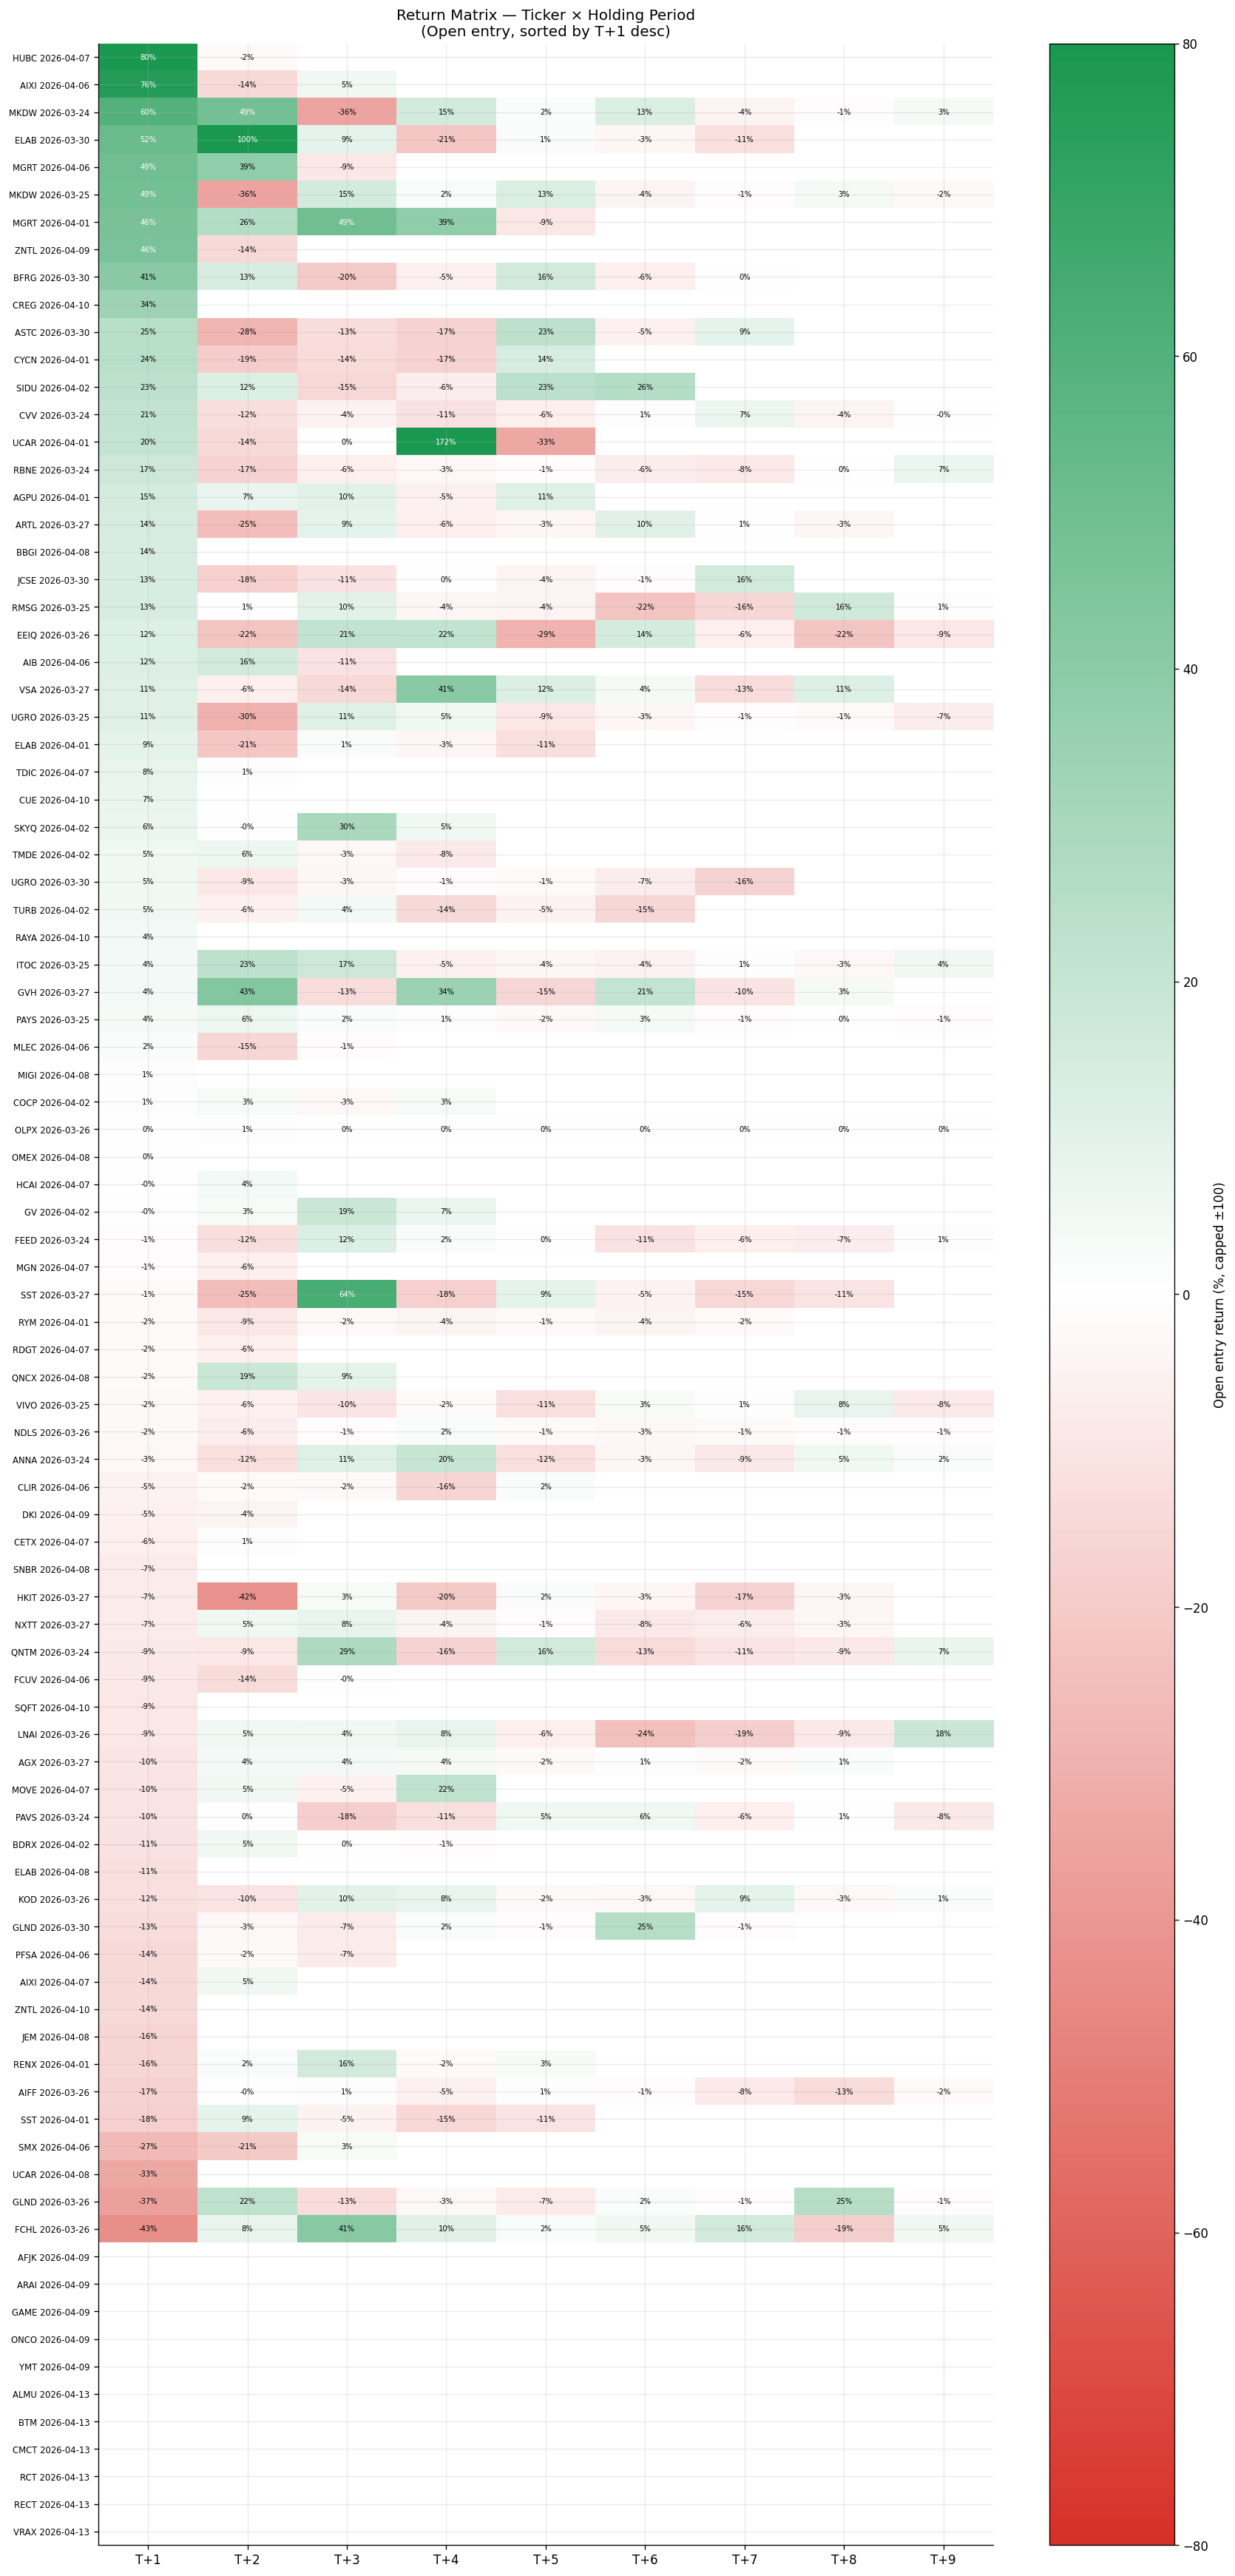

In [186]:
# ── Return heatmap: ticker × day ──────────────────────────────────────────────
ret_cols = [f'T{t}_ret_open' for t in range(1, 10)]

# Create a label: ticker + burst_date
events['label'] = events.apply(lambda r: f"{r['ticker']} {r['burst_date']}", axis=1)
heat = events.set_index('label')[ret_cols].copy()
heat.columns = [f'T+{t}' for t in range(1,10)]
heat = heat.sort_values('T+1', ascending=False)

# Cap at ±100% for visualization
heat_display = heat.clip(-100, 100)

vmax = min(heat_display.abs().max().max(), 80)
cmap = LinearSegmentedColormap.from_list('rwg', ['#d73027','white','#1a9850'])

fig_h = max(10, len(heat_display) * 0.32)
fig, ax = plt.subplots(figsize=(14, fig_h))

im = ax.imshow(heat_display.values, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(9))
ax.set_xticklabels(heat_display.columns, fontsize=10)
ax.set_yticks(range(len(heat_display)))
ax.set_yticklabels(heat_display.index, fontsize=7)

for i in range(len(heat_display)):
    for j in range(9):
        v = heat.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=6,
                    color='white' if abs(v) > vmax*0.55 else 'black')

plt.colorbar(im, ax=ax, label='Open entry return (%, capped ±100)')
ax.set_title('Return Matrix — Ticker × Holding Period\n(Open entry, sorted by T+1 desc)', fontsize=12)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'v2_fig09_heatmap.png', bbox_inches='tight', dpi=100)
plt.show()

## 11. Intraday T+1 Analysis — MFE, MAE & Dip-Recover Patterns

**Objective**: For each burst event, download 1-min bars of the T+1 day and analyze:
- **MAE** (Maximum Adverse Excursion from open): how deep does the stock dip before any recovery?
- **MFE** (Maximum Favorable Excursion from open): the best price reached during the session
- **Pattern classification**: Gap-and-Go / Dip-then-Recover / Fade-all-day
- **Optimal intraday entry**: does waiting for the dip bottom improve R/R vs buying at open?
- **Predictors of dip-recover**: can burst day candle quality or gap predict which path a stock takes?

In [187]:
# ── Download T+1 intraday 1-min bars from IBKR ──────────────────────────────
import nest_asyncio
nest_asyncio.apply()
from ib_insync import IB, Stock, util
import time, pytz
util.logToConsole(False)

INTRA_CACHE = ANALYSIS_DIR / 'burst_intraday_cache.db'

# Setup cache DB
import sqlite3 as _sq
_ic = _sq.connect(str(INTRA_CACHE))
_ic.execute("""
    CREATE TABLE IF NOT EXISTS bars (
        symbol TEXT, date TEXT, dt TEXT,
        open REAL, high REAL, low REAL, close REAL, volume INTEGER,
        PRIMARY KEY (symbol, date, dt)
    )
""")
_ic.execute("CREATE TABLE IF NOT EXISTS fetched (symbol TEXT, date TEXT, PRIMARY KEY(symbol,date))")
_ic.commit()

def already_fetched_intra(conn, symbol, date_str):
    return conn.execute('SELECT 1 FROM fetched WHERE symbol=? AND date=?', (symbol, date_str)).fetchone() is not None

# Build list of (ticker, T+1_date) needed
intra_needed = []
for _, b in burst.iterrows():
    bd = pd.Timestamp(b['date']).date()
    future = [d for d in all_trading_days if d > bd]
    if not future:
        continue
    t1d = str(future[0])
    if not already_fetched_intra(_ic, b['ticker'], t1d):
        intra_needed.append((b['ticker'], t1d))

print(f'Intraday bars to download: {len(intra_needed)}')
print(f'Already cached: {_ic.execute("SELECT COUNT(DISTINCT symbol||date) FROM fetched").fetchone()[0]}')

if intra_needed:
    ib2 = IB()
    ib2.connect('127.0.0.1', 7497, clientId=91)
    print(f'Connected: {ib2.isConnected()}')

    ok, err = 0, 0
    for i, (sym, date_str) in enumerate(intra_needed):
        contract = Stock(sym, 'SMART', 'USD')
        next_day = (pd.Timestamp(date_str) + pd.Timedelta(days=1)).strftime('%Y%m%d 00:00:00')
        try:
            bars = ib2.reqHistoricalData(
                contract, endDateTime=next_day,
                durationStr='1 D', barSizeSetting='1 min',
                whatToShow='TRADES', useRTH=True,
                formatDate=2, keepUpToDate=False, timeout=25,
            )
            if bars:
                rows_to_insert = [
                    (sym, date_str,
                     b.date.astimezone(pytz.timezone('America/New_York')).strftime('%H:%M'),
                     b.open, b.high, b.low, b.close, b.volume)
                    for b in bars
                ]
                _ic.executemany('INSERT OR REPLACE INTO bars VALUES (?,?,?,?,?,?,?,?)', rows_to_insert)
                _ic.execute('INSERT OR REPLACE INTO fetched VALUES (?,?)', (sym, date_str))
                _ic.commit()
                ok += 1
            else:
                _ic.execute('INSERT OR REPLACE INTO fetched VALUES (?,?)', (sym, date_str))
                _ic.commit()
                err += 1
        except Exception as e:
            err += 1
            print(f'  ERROR {sym} {date_str}: {e}')

        if (i+1) % 15 == 0:
            print(f'  [{i+1}/{len(intra_needed)}] ok={ok} err={err}')
        time.sleep(0.45)

    ib2.disconnect()
    print(f'Done: ok={ok} err={err}')
else:
    print('All intraday data already cached')

_ic.close()
print(f'Cache: {INTRA_CACHE}')

Intraday bars to download: 0
Already cached: 88
All intraday data already cached
Cache: /Users/carlos/proyectos/TRADING/1_PROYECTOS_ACTIVOS/CLAUDE/finviz-dashboard/analysis/burst_intraday_cache.db


In [188]:
# ── Load intraday bars & compute MFE/MAE per event ───────────────────────────
import sqlite3 as _sq, pytz

ET = pytz.timezone('America/New_York')

def get_intra(symbol, date_str):
    conn = _sq.connect(str(INTRA_CACHE))
    rows = conn.execute(
        'SELECT dt, open, high, low, close, volume FROM bars WHERE symbol=? AND date=? ORDER BY dt',
        (symbol, date_str)
    ).fetchall()
    conn.close()
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows, columns=['time','open','high','low','close','volume'])
    # Filter to regular session 09:30 - 16:00
    df = df[(df['time'] >= '09:30') & (df['time'] <= '15:59')].copy()
    df['minute'] = df['time'].apply(lambda t: int(t[:2])*60 + int(t[3:]) - 9*60 - 30)
    return df.reset_index(drop=True)

intra_records = []

for _, b in burst.iterrows():
    sym = b['ticker']
    bd  = pd.Timestamp(b['date']).date()
    future = [d for d in all_trading_days if d > bd]
    if not future:
        continue
    t1d_str = str(future[0])

    df = get_intra(sym, t1d_str)
    if df.empty or len(df) < 20:
        continue

    # Reference: T+1 open price
    open_px = df['open'].iloc[0]
    if open_px <= 0:
        continue

    # Burst day context from events DataFrame
    ev_row = events[(events['ticker'] == sym) & (events['burst_date'] == bd)]
    if ev_row.empty:
        continue
    ev = ev_row.iloc[0]

    trigger   = float(ev.get('trigger', 0))
    burst_close = float(ev.get('burst_close', 0))

    # Cumulative max/min from open at each bar
    df['ret_from_open'] = (df['close'] - open_px) / open_px * 100
    df['cum_high']      = df['high'].expanding().max()
    df['cum_low']       = df['low'].expanding().min()
    df['mfe_running']   = (df['cum_high'] - open_px) / open_px * 100
    df['mae_running']   = (df['cum_low']  - open_px) / open_px * 100

    close_px = df['close'].iloc[-1]
    mfe      = df['mfe_running'].iloc[-1]   # max gain achieved at any point
    mae      = df['mae_running'].iloc[-1]   # max drawdown from open
    day_ret  = (close_px - open_px) / open_px * 100

    # Time of MFE and MAE
    mfe_minute = int(df.loc[df['high'] == df['cum_high'].iloc[-1], 'minute'].iloc[-1])
    mae_minute = int(df.loc[df['low']  == df['cum_low'].iloc[-1],  'minute'].iloc[-1])

    # Opening range: first 30 min
    or30 = df[df['minute'] <= 30]
    or30_high = or30['high'].max() if not or30.empty else np.nan
    or30_low  = or30['low'].min()  if not or30.empty else np.nan
    or30_ret  = (or30['close'].iloc[-1] - open_px) / open_px * 100 if not or30.empty else np.nan

    # Pattern classification
    # 1. Gap-and-Go: MAE < 3% AND MFE > 5% — virtually no dip, trends up
    # 2. Dip-Recover: MAE < -3% AND day_ret > 0 — dipped but recovered
    # 3. Fade: day_ret < -5% — sold off all day
    # 4. Chop: everything else
    if mae > -3.0 and mfe > 5.0 and day_ret > 0:
        pattern = 'GAP_AND_GO'
    elif mae < -3.0 and day_ret > 0:
        pattern = 'DIP_RECOVER'
    elif day_ret < -5.0:
        pattern = 'FADE'
    else:
        pattern = 'CHOP'

    # For DIP_RECOVER: optimal entry = low of first 60 min?
    first60 = df[df['minute'] <= 60]
    dip_entry_px = first60['low'].min() if not first60.empty else np.nan
    dip_entry_ret = (close_px - dip_entry_px) / dip_entry_px * 100 if dip_entry_px and dip_entry_px > 0 else np.nan

    # ── VWAP computation (cumulative TP*V / cumV) ──────────────────────
    if 'volume' in df.columns and df['volume'].sum() > 0:
        df['tp']   = (df['high'] + df['low'] + df['close']) / 3
        df['vwap'] = (df['tp'] * df['volume']).cumsum() / df['volume'].replace(0, np.nan).cumsum()
        df['vwap'] = df['vwap'].ffill()
    else:
        df['vwap'] = np.nan

    # VWAP cross: first minute price (close) crosses from below to above VWAP
    crosses = df[(df['close'] > df['vwap']) & (df['close'].shift(1) <= df['vwap'].shift(1))]
    if not crosses.empty:
        cx = crosses.iloc[0]
        vwap_cross_minute = int(cx['minute'])
        vwap_cross_px     = float(cx['close'])
        vwap_cross_ret    = (close_px - vwap_cross_px) / vwap_cross_px * 100
    else:
        vwap_cross_minute = np.nan
        vwap_cross_px     = np.nan
        vwap_cross_ret    = np.nan

    # Open-bar VWAP (is first bar close above VWAP? proxy for immediate momentum)
    open_above_vwap = bool(df.iloc[0]['close'] > df.iloc[0]['vwap']) if not df['vwap'].isna().all() else np.nan

    # VWAP at 30 min mark
    vwap_30 = df[df['minute'] <= 30]['vwap'].iloc[-1] if not df[df['minute'] <= 30].empty else np.nan

    intra_records.append({
        'ticker':         sym,
        'burst_date':     bd,
        't1_date':        t1d_str,
        'candle_green':   ev['candle_green'],
        'close_pos':      ev['close_pos'],
        'ibkr_chg':       ev['ibkr_chg'],
        'presence_pct':   ev['presence_pct'],
        't1_open':        open_px,
        't1_close':       close_px,
        'gap_vs_trigger': (open_px - trigger) / trigger * 100 if trigger > 0 else np.nan,
        'mfe':            mfe,
        'mae':            mae,
        'day_ret':        day_ret,
        'mfe_minute':     mfe_minute,
        'mae_minute':     mae_minute,
        'mfe_mae_ratio':  abs(mfe / mae) if mae < 0 else np.nan,
        'or30_ret':       or30_ret,
        'pattern':        pattern,
        'dip_entry_ret':   dip_entry_ret,
        'n_bars':          len(df),
        # VWAP fields
        'vwap_cross_minute': vwap_cross_minute,
        'vwap_cross_px':     vwap_cross_px,
        'vwap_cross_ret':    vwap_cross_ret,
        'open_above_vwap':   open_above_vwap,
        'vwap_30':           vwap_30,
        'open_vs_vwap30':    (open_px - vwap_30) / vwap_30 * 100 if vwap_30 and vwap_30 > 0 else np.nan,
    })

intra = pd.DataFrame(intra_records)
print(f'Events with intraday data: {len(intra)}')
print()
print('Pattern distribution:')
print(intra['pattern'].value_counts())
print()
print('Summary by pattern:')
print(intra.groupby('pattern')[['mfe','mae','day_ret','dip_entry_ret']].agg(['mean','median']).round(2))

Events with intraday data: 85

Pattern distribution:
pattern
DIP_RECOVER    31
FADE           28
CHOP           16
GAP_AND_GO     10
Name: count, dtype: int64

Summary by pattern:
               mfe            mae         day_ret         dip_entry_ret       
              mean median    mean  median    mean  median          mean median
pattern                                                                       
CHOP         9.550  5.560 -11.070  -9.250  -1.800  -1.630         8.500  8.460
DIP_RECOVER 33.110 22.070  -8.700  -8.080  20.450  12.360        31.130 24.300
FADE         6.880  4.560 -21.870 -19.210 -15.410 -13.010        -1.150 -2.250
GAP_AND_GO  42.020 43.100  -1.100  -0.590  31.360  31.700        32.720 33.400


In [ ]:
# ── VWAP Entry Analysis ───────────────────────────────────────────────────────
# Question 1: Does entering at VWAP cross beat open entry?
# Question 2: Does gap_vs_trigger predict day_ret? Is there a useful filter threshold?
from scipy.stats import ttest_1samp, mannwhitneyu, ttest_ind

print('=' * 70)
print('DIRECTIONAL & VWAP ANALYSIS')
print('=' * 70)

# ── 1. gap_vs_trigger segmentation ───────────────────────────────────────────
print('\n--- H1: Does T+1 gap_vs_trigger predict day return? ---')
bins_labels = [
    ('Above trigger (>= 0%)',     intra['gap_vs_trigger'] >= 0),
    ('Mild gap (-5% to 0%)',      (intra['gap_vs_trigger'] >= -5) & (intra['gap_vs_trigger'] < 0)),
    ('Deep gap (-10% to -5%)',    (intra['gap_vs_trigger'] >= -10) & (intra['gap_vs_trigger'] < -5)),
    ('Extreme gap (< -10%)',      intra['gap_vs_trigger'] < -10),
]
print(f'  {"Segment":30s}  {"n":>4}  {"WR":>6}  {"Mean day_ret":>12}  {"Mean MFE":>9}  {"Mean MAE":>9}  {"p":>7}')
print(f'  {"-"*80}')
for label, mask in bins_labels:
    s = intra[mask]['day_ret'].dropna()
    if len(s) < 3:
        print(f'  {label:30s}  {len(s):>4}  N/A')
        continue
    _, p = ttest_1samp(s, 0)
    mfe_m = intra[mask]['mfe'].mean()
    mae_m = intra[mask]['mae'].mean()
    print(f'  {label:30s}  {len(s):>4}  {(s>0).mean():>6.0%}  {s.mean():>+12.1f}%  {mfe_m:>+9.1f}%  {mae_m:>+9.1f}%  {p:>7.4f}' +
          ('  ***' if p < 0.05 else ''))

# Mann-Whitney test: above trigger vs below
above = intra[intra['gap_vs_trigger'] >= 0]['day_ret'].dropna()
below = intra[intra['gap_vs_trigger'] <  0]['day_ret'].dropna()
if len(above) >= 3 and len(below) >= 3:
    _, p_mw = mannwhitneyu(above, below, alternative='two-sided')
    print(f'\n  Mann-Whitney (above vs below trigger): p={p_mw:.4f}' +
          ('  *** SIGNIFICANT' if p_mw < 0.05 else '  (not significant)'))

# ── 2. VWAP cross entry ───────────────────────────────────────────────────────
print('\n--- H2: VWAP cross entry vs open entry ---')
has_cross = intra['vwap_cross_minute'].notna()
print(f'  Events with VWAP cross: {has_cross.sum()} / {len(intra)} ({has_cross.mean():.0%})')
print(f'  Events with NO cross (price never broke above VWAP): {(~has_cross).sum()}')

vwap_subset = intra[has_cross].copy()
if len(vwap_subset) >= 5:
    open_ret  = vwap_subset['day_ret'].dropna()
    vwap_ret  = vwap_subset['vwap_cross_ret'].dropna()
    _, p_open = ttest_1samp(open_ret, 0)
    _, p_vwap = ttest_1samp(vwap_ret, 0)
    print(f'\n  Same events (n={len(vwap_subset)}, those with VWAP cross):')
    print(f'    Open entry:       mean={open_ret.mean():+.1f}%  WR={(open_ret>0).mean():.0%}  p={p_open:.4f}')
    print(f'    VWAP cross entry: mean={vwap_ret.mean():+.1f}%  WR={(vwap_ret>0).mean():.0%}  p={p_vwap:.4f}')
    if len(open_ret) == len(vwap_ret):
        diff = vwap_ret.values - open_ret.values
        _, p_diff = ttest_1samp(diff, 0)
        print(f'    VWAP improvement vs open: {diff.mean():+.1f}% (p={p_diff:.4f})')

    print(f'\n  VWAP cross timing:')
    print(f'    Median cross minute: {vwap_subset["vwap_cross_minute"].median():.0f} '
          f'(~{9+(vwap_subset["vwap_cross_minute"].median()+30)//60:.0f}:{(int(vwap_subset["vwap_cross_minute"].median())+30)%60:02d} ET)')
    print(f'    Early cross (<= 30 min): {(vwap_subset["vwap_cross_minute"] <= 30).sum()}')
    print(f'    Late cross (> 60 min):   {(vwap_subset["vwap_cross_minute"] > 60).sum()}')

    # Early cross vs late cross return
    early = vwap_subset[vwap_subset['vwap_cross_minute'] <= 30]['vwap_cross_ret'].dropna()
    late  = vwap_subset[vwap_subset['vwap_cross_minute'] >  60]['vwap_cross_ret'].dropna()
    if len(early) >= 3 and len(late) >= 3:
        _, p_el = mannwhitneyu(early, late, alternative='two-sided')
        print(f'    Early cross ret: mean={early.mean():+.1f}% WR={(early>0).mean():.0%}')
        print(f'    Late  cross ret: mean={late.mean():+.1f}% WR={(late>0).mean():.0%}  p(diff)={p_el:.4f}')

# ── 3. open_above_vwap as filter ─────────────────────────────────────────────
print('\n--- H3: First bar close above VWAP → better edge? ---')
oav = intra['open_above_vwap'].notna()
if oav.sum() >= 5:
    above_v = intra[intra['open_above_vwap'] == True]['day_ret'].dropna()
    below_v = intra[intra['open_above_vwap'] == False]['day_ret'].dropna()
    print(f'  Open bar above VWAP:  n={len(above_v)}  mean={above_v.mean():+.1f}%  WR={(above_v>0).mean():.0%}')
    print(f'  Open bar below VWAP:  n={len(below_v)}  mean={below_v.mean():+.1f}%  WR={(below_v>0).mean():.0%}')
    if len(above_v) >= 3 and len(below_v) >= 3:
        _, p_v = mannwhitneyu(above_v, below_v, alternative='two-sided')
        print(f'  Mann-Whitney p={p_v:.4f}' + ('  ***' if p_v < 0.05 else ''))

# ── 4. Visualization ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Directional & VWAP Analysis — T+1 Open Entry', fontweight='bold')

# A: day_ret by gap_vs_trigger bucket
ax = axes[0][0]
intra['gap_bucket3'] = pd.cut(intra['gap_vs_trigger'].clip(-15, 15),
    bins=[-15,-10,-5,-2,0,5,15],
    labels=['<-10','(-10,-5)','(-5,-2)','(-2,0)','(0,5)','>5'])
bucket_means = intra.groupby('gap_bucket3')['day_ret'].agg(['mean','sem','count'])
colors_b = ['#D32F2F','#F44336','#FF7043','#FFAB91','#4CAF50','#1B5E20']
bars = ax.bar(bucket_means.index, bucket_means['mean'],
              yerr=bucket_means['sem'],
              color=colors_b[:len(bucket_means)], alpha=0.8, capsize=4)
ax.axhline(0, color='black', linewidth=0.8)
for i, (idx_b, row_b) in enumerate(bucket_means.iterrows()):
    ax.text(i, row_b['mean'] + row_b['sem'] + 0.5, f"n={int(row_b['count'])}", ha='center', fontsize=8)
ax.set_xlabel('T+1 gap vs trigger (%)')
ax.set_ylabel('Mean day return (%)')
ax.set_title('Day Return by Gap vs Trigger Bucket')

# B: WR by gap bucket
ax = axes[0][1]
wr_by_bucket = intra.groupby('gap_bucket3')['day_ret'].apply(lambda x: (x > 0).mean())
ax.bar(wr_by_bucket.index, wr_by_bucket * 100,
       color=['#4CAF50' if v > 0.5 else '#F44336' for v in wr_by_bucket], alpha=0.8)
ax.axhline(50, color='black', linewidth=1, linestyle='--', label='50%')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Win Rate by Gap vs Trigger Bucket')
ax.legend(fontsize=9)

# C: VWAP cross timing distribution
ax = axes[0][2]
if has_cross.sum() >= 3:
    ax.hist(vwap_subset['vwap_cross_minute'].dropna(), bins=20, color='#2196F3', alpha=0.8)
    ax.axvline(30, color='orange', linestyle='--', label='30 min mark')
    ax.axvline(60, color='red',    linestyle='--', label='60 min mark')
    ax.set_xlabel('Minutes after open')
    ax.set_ylabel('N events')
    ax.set_title('VWAP Cross Timing Distribution')
    ax.legend(fontsize=9)

# D: VWAP cross return vs open entry scatter
ax = axes[1][0]
if len(vwap_subset) >= 3:
    ax.scatter(vwap_subset['day_ret'], vwap_subset['vwap_cross_ret'],
               c=vwap_subset['gap_vs_trigger'].clip(-15,15), cmap='RdYlGn',
               alpha=0.7, s=60, vmin=-15, vmax=15)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    lim = max(abs(vwap_subset['day_ret'].max()), abs(vwap_subset['vwap_cross_ret'].max()), 20)
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, alpha=0.4, label='y=x (same return)')
    ax.set_xlabel('Open entry return (%)')
    ax.set_ylabel('VWAP cross entry return (%)')
    ax.set_title('VWAP Cross vs Open Entry\n(color = gap_vs_trigger)')
    ax.legend(fontsize=9)

# E: day_ret by open_above_vwap (first bar)
ax = axes[1][1]
if intra['open_above_vwap'].notna().sum() >= 5:
    g_above = intra[intra['open_above_vwap'] == True]['day_ret'].dropna()
    g_below = intra[intra['open_above_vwap'] == False]['day_ret'].dropna()
    bp_data = [g_above, g_below]
    bp = ax.boxplot(bp_data, labels=[f'Above VWAP\n(n={len(g_above)})', f'Below VWAP\n(n={len(g_below)})'],
                    patch_artist=True, notch=False)
    bp['boxes'][0].set_facecolor('#4CAF50'); bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#F44336'); bp['boxes'][1].set_alpha(0.6)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel('Day Return (%)')
    ax.set_title('Day Return by First-Bar VWAP Position')

# F: gap_vs_trigger vs MFE scatter
ax = axes[1][2]
valid = intra.dropna(subset=['gap_vs_trigger','mfe','mae'])
sc = ax.scatter(valid['gap_vs_trigger'], valid['mfe'],
                c=valid['mae'].clip(-30, 0), cmap='RdYlGn_r',
                alpha=0.6, s=50, vmin=-30, vmax=0)
plt.colorbar(sc, ax=ax, label='MAE (%)')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', label='Trigger level')
z = np.polyfit(valid['gap_vs_trigger'], valid['mfe'], 1)
xr = np.linspace(valid['gap_vs_trigger'].min(), valid['gap_vs_trigger'].max(), 50)
ax.plot(xr, np.poly1d(z)(xr), 'b--', linewidth=1.5, label=f'slope={z[0]:.2f}')
ax.set_xlabel('T+1 gap vs trigger (%)')
ax.set_ylabel('MFE (%)')
ax.set_title('Gap vs Trigger → MFE\n(color = MAE)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(str(ANALYSIS_DIR / 'v2_fig_directional_vwap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\nChart saved: v2_fig_directional_vwap.png')


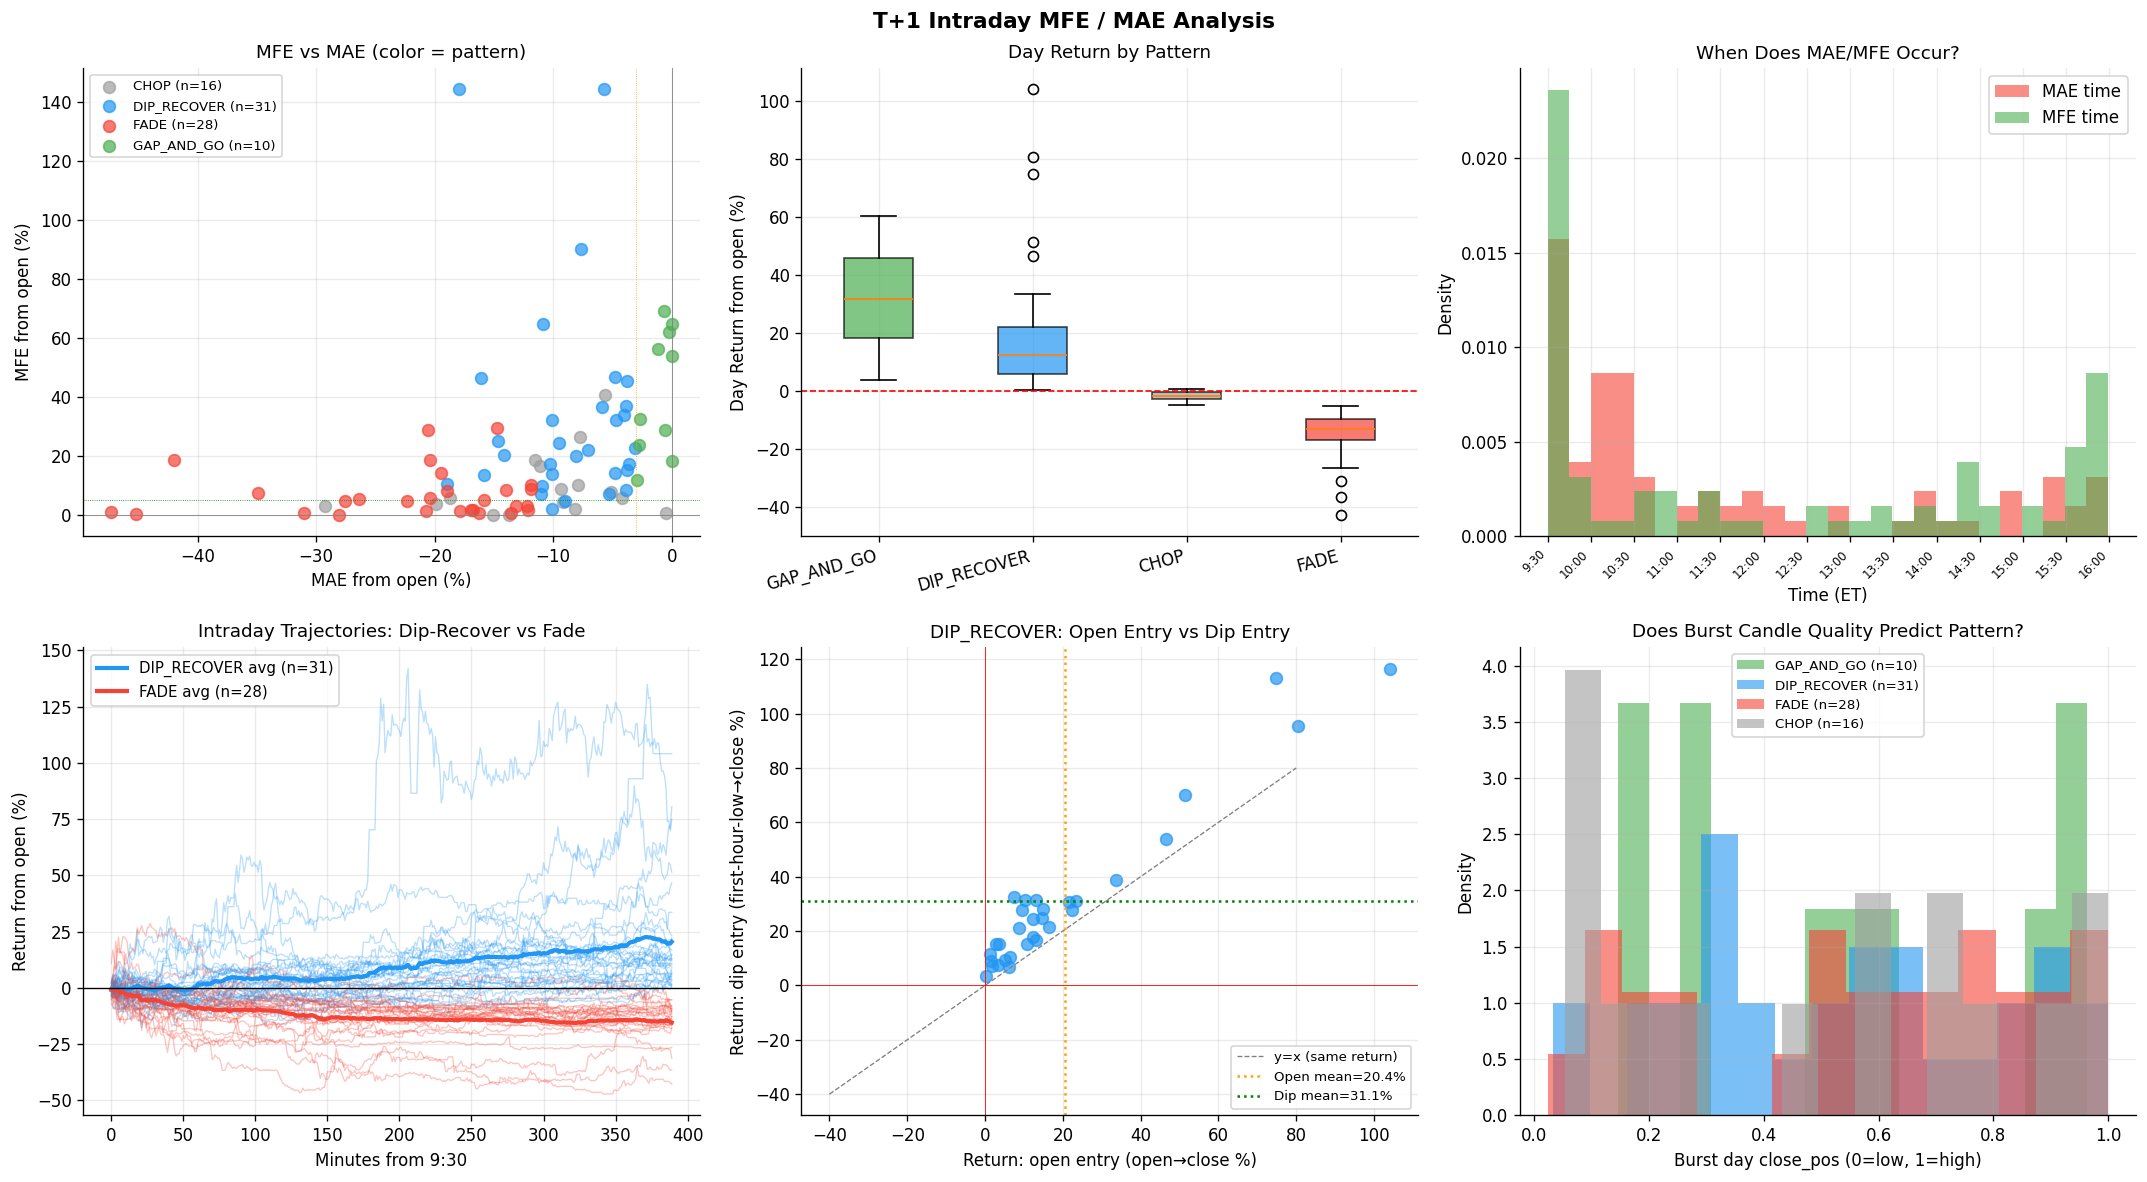

In [189]:
# ── MFE vs MAE Scatter & Pattern Overview ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('T+1 Intraday MFE / MAE Analysis', fontweight='bold')

PAT_COLORS = {'GAP_AND_GO': '#4CAF50', 'DIP_RECOVER': '#2196F3', 'FADE': '#F44336', 'CHOP': '#9E9E9E'}

# ── MFE vs MAE scatter ──────────────────────────────────────────────────────
ax = axes[0][0]
for pat, grp in intra.groupby('pattern'):
    ax.scatter(grp['mae'], grp['mfe'], color=PAT_COLORS[pat], alpha=0.7, s=50, label=f'{pat} (n={len(grp)})')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.axhline(5,  color='green',  linewidth=0.5, linestyle=':')
ax.axvline(-3, color='orange', linewidth=0.5, linestyle=':')
ax.set_xlabel('MAE from open (%)')
ax.set_ylabel('MFE from open (%)')
ax.set_title('MFE vs MAE (color = pattern)')
ax.legend(fontsize=8)

# ── Day return by pattern ────────────────────────────────────────────────────
ax = axes[0][1]
pat_order = ['GAP_AND_GO', 'DIP_RECOVER', 'CHOP', 'FADE']
pat_data = [intra[intra['pattern']==p]['day_ret'].dropna() for p in pat_order if p in intra['pattern'].values]
pat_labels = [p for p in pat_order if p in intra['pattern'].values]
bp = ax.boxplot(pat_data, labels=pat_labels, patch_artist=True, notch=False)
for patch, lbl in zip(bp['boxes'], pat_labels):
    patch.set_facecolor(PAT_COLORS[lbl])
    patch.set_alpha(0.7)
ax.axhline(0, color='red', linewidth=1, linestyle='--')
ax.set_ylabel('Day Return from open (%)')
ax.set_title('Day Return by Pattern')
ax.set_xticklabels(pat_labels, rotation=15, ha='right')

# ── Time of MFE and MAE ──────────────────────────────────────────────────────
ax = axes[0][2]
ax.hist(intra['mae_minute'].dropna(), bins=26, color='#F44336', alpha=0.6,
        label='MAE time', density=True)
ax.hist(intra['mfe_minute'].dropna(), bins=26, color='#4CAF50', alpha=0.6,
        label='MFE time', density=True)
tick_min = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390]
tick_lbl = ['9:30','10:00','10:30','11:00','11:30','12:00','12:30','13:00','13:30','14:00','14:30','15:00','15:30','16:00']
ax.set_xticks(tick_min)
ax.set_xticklabels(tick_lbl, rotation=45, ha='right', fontsize=7)
ax.set_xlabel('Time (ET)')
ax.set_ylabel('Density')
ax.set_title('When Does MAE/MFE Occur?')
ax.legend()

# ── Open → dip → recover trajectories ───────────────────────────────────────
ax = axes[1][0]
for _, b in burst.iterrows():
    sym = b['ticker']
    bd  = pd.Timestamp(b['date']).date()
    future = [d for d in all_trading_days if d > bd]
    if not future: continue
    t1d_str = str(future[0])
    row = intra[(intra['ticker']==sym) & (intra['burst_date']==bd)]
    if row.empty: continue
    pat = row.iloc[0]['pattern']
    if pat not in ('DIP_RECOVER', 'FADE'): continue  # show dips only
    df = get_intra(sym, t1d_str)
    if df.empty: continue
    open_px = df['open'].iloc[0]
    if open_px <= 0: continue
    ret = (df['close'] - open_px) / open_px * 100
    color = '#2196F3' if pat == 'DIP_RECOVER' else '#F44336'
    ax.plot(df['minute'].values, ret.values, color=color, alpha=0.3, linewidth=0.8)

# Average trajectory by pattern
for pat, col in [('DIP_RECOVER','#2196F3'), ('FADE','#F44336')]:
    pat_rows = intra[intra['pattern']==pat]
    curves = []
    for _, r in pat_rows.iterrows():
        df = get_intra(r['ticker'], r['t1_date'])
        if df.empty: continue
        opx = df['open'].iloc[0]
        if opx <= 0: continue
        ret = (df['close'] - opx) / opx * 100
        curves.append(ret.values[:390])
    if curves:
        min_len = min(len(c) for c in curves)
        avg = np.mean([c[:min_len] for c in curves], axis=0)
        ax.plot(range(min_len), avg, color=col, linewidth=2.5, label=f'{pat} avg (n={len(curves)})')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Minutes from 9:30')
ax.set_ylabel('Return from open (%)')
ax.set_title('Intraday Trajectories: Dip-Recover vs Fade')
ax.legend(fontsize=9)

# ── Open-entry vs dip-entry comparison ──────────────────────────────────────
ax = axes[1][1]
dip_rec = intra[intra['pattern']=='DIP_RECOVER']
ax.scatter(dip_rec['day_ret'], dip_rec['dip_entry_ret'], alpha=0.7, s=50, color='#2196F3')
ax.plot([-40,80],[-40,80], 'gray', linewidth=0.8, linestyle='--', label='y=x (same return)')
ax.axhline(0, color='red', linewidth=0.5)
ax.axvline(0, color='red', linewidth=0.5)
mu_open = dip_rec['day_ret'].mean()
mu_dip  = dip_rec['dip_entry_ret'].mean()
ax.axvline(mu_open, color='orange', linewidth=1.5, linestyle=':', label=f'Open mean={mu_open:.1f}%')
ax.axhline(mu_dip,  color='green',  linewidth=1.5, linestyle=':', label=f'Dip mean={mu_dip:.1f}%')
ax.set_xlabel('Return: open entry (open→close %)')
ax.set_ylabel('Return: dip entry (first-hour-low→close %)')
ax.set_title('DIP_RECOVER: Open Entry vs Dip Entry')
ax.legend(fontsize=8)

# ── Predictor: burst day close_pos → pattern ────────────────────────────────
ax = axes[1][2]
for pat, col in [('GAP_AND_GO','#4CAF50'),('DIP_RECOVER','#2196F3'),('FADE','#F44336'),('CHOP','#9E9E9E')]:
    s = intra[intra['pattern']==pat]['close_pos'].dropna()
    if len(s) >= 3:
        ax.hist(s, bins=15, color=col, alpha=0.6, density=True, label=f'{pat} (n={len(s)})')
ax.set_xlabel('Burst day close_pos (0=low, 1=high)')
ax.set_ylabel('Density')
ax.set_title('Does Burst Candle Quality Predict Pattern?')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'v2_fig10_intraday_mfe_mae.png', bbox_inches='tight')
plt.show()

In [190]:
# ── Statistical Predictors of DIP_RECOVER vs FADE ────────────────────────────
# Key question: can we predict BEFORE the open whether a stock will dip-recover or fade?
# Predictors available pre-market: burst_chg, candle_green, close_pos, presence_pct, gap_vs_trigger

from scipy.stats import ttest_ind, mannwhitneyu

intra['is_winner'] = intra['day_ret'] > 0  # positive day from open
intra['is_dip_recover'] = intra['pattern'] == 'DIP_RECOVER'
intra['is_fade'] = intra['pattern'] == 'FADE'

print('=== PREDICTORS OF WINNER (day_ret > 0) vs LOSER ===')
for pred in ['ibkr_chg','close_pos','presence_pct','gap_vs_trigger','vwap_cross_minute','open_above_vwap']:
    w = intra[intra['is_winner']][pred].dropna()
    l = intra[~intra['is_winner']][pred].dropna()
    if len(w) < 3 or len(l) < 3: continue
    _, p = mannwhitneyu(w, l, alternative='two-sided')
    print(f'  {pred:20s}: winners mean={w.mean():.2f}  losers mean={l.mean():.2f}  p={p:.4f}'
          + ('  *** predictive' if p < 0.05 else ''))

print()
print('=== DIP_RECOVER vs FADE: pre-market predictors ===')
dr = intra[intra['is_dip_recover']]
fd = intra[intra['is_fade']]
for pred in ['ibkr_chg','close_pos','presence_pct','gap_vs_trigger','mae','vwap_cross_minute','open_above_vwap']:
    w = dr[pred].dropna()
    l = fd[pred].dropna()
    if len(w) < 3 or len(l) < 3: continue
    _, p = mannwhitneyu(w, l, alternative='two-sided')
    print(f'  {pred:20s}: DIP_RECOVER={w.mean():.2f}  FADE={l.mean():.2f}  p={p:.4f}'
          + ('  *** predictive' if p < 0.05 else ''))

print()
print('=== OPTIMAL ENTRY TIME ANALYSIS ===')
# For each time window, compute mean return if we enter at that minute (buy close of that bar)
entry_times = [0, 5, 10, 15, 30, 60, 90, 120]
print(f'{"Entry at minute":20s}  {"n":>4}  {"Mean ret":>9}  {"WR":>6}  {"vs open":>8}')

open_mean = intra['day_ret'].mean()

for entry_min in entry_times:
    rets = []
    for _, b in burst.iterrows():
        sym = b['ticker']
        bd  = pd.Timestamp(b['date']).date()
        future = [d for d in all_trading_days if d > bd]
        if not future: continue
        df = get_intra(sym, str(future[0]))
        if df.empty or len(df) < entry_min + 5: continue
        if entry_min == 0:
            entry_px = df['open'].iloc[0]
        else:
            bar_at = df[df['minute'] >= entry_min]
            if bar_at.empty: continue
            entry_px = bar_at['close'].iloc[0]
        exit_px = df['close'].iloc[-1]
        if entry_px > 0:
            rets.append((exit_px - entry_px) / entry_px * 100)
    if len(rets) >= 5:
        s = pd.Series(rets)
        lbl = f'9:{30+entry_min:02d}' if entry_min < 30 else f'{9+(entry_min+30)//60}:{(30+entry_min)%60:02d}'
        print(f'  {lbl:20s}  {len(s):>4}  {s.mean():>+9.2f}%  {(s>0).mean():>6.1%}  {s.mean()-open_mean:>+8.2f}%')

=== PREDICTORS OF WINNER (day_ret > 0) vs LOSER ===
  ibkr_chg            : winners mean=97.12  losers mean=70.26  p=0.2477
  close_pos           : winners mean=0.54  losers mean=0.52  p=0.7153
  presence_pct        : winners mean=0.74  losers mean=0.69  p=0.2985
  gap_vs_trigger      : winners mean=-26.33  losers mean=45.67  p=0.5182

=== DIP_RECOVER vs FADE: pre-market predictors ===
  ibkr_chg            : DIP_RECOVER=104.21  FADE=77.83  p=0.6111
  close_pos           : DIP_RECOVER=0.53  FADE=0.57  p=0.6764
  presence_pct        : DIP_RECOVER=0.76  FADE=0.69  p=0.2479
  gap_vs_trigger      : DIP_RECOVER=-27.44  FADE=11.66  p=0.4709
  mae                 : DIP_RECOVER=-8.70  FADE=-21.87  p=0.0000  *** predictive

=== OPTIMAL ENTRY TIME ANALYSIS ===
Entry at minute          n   Mean ret      WR   vs open
  9:30                    87      +5.16%   48.3%     -0.57%
  9:35                    87      +5.59%   50.6%     -0.14%
  9:40                    87      +5.76%   58.6%     +0.03%
  9

2026-04-14 08:04:37,579 matplotlib.colorbar DEBUG locator: <matplotlib.ticker.AutoLocator object at 0x3126e4b00>
2026-04-14 08:04:37,878 matplotlib.colorbar DEBUG locator: <matplotlib.ticker.AutoLocator object at 0x17a1b5310>


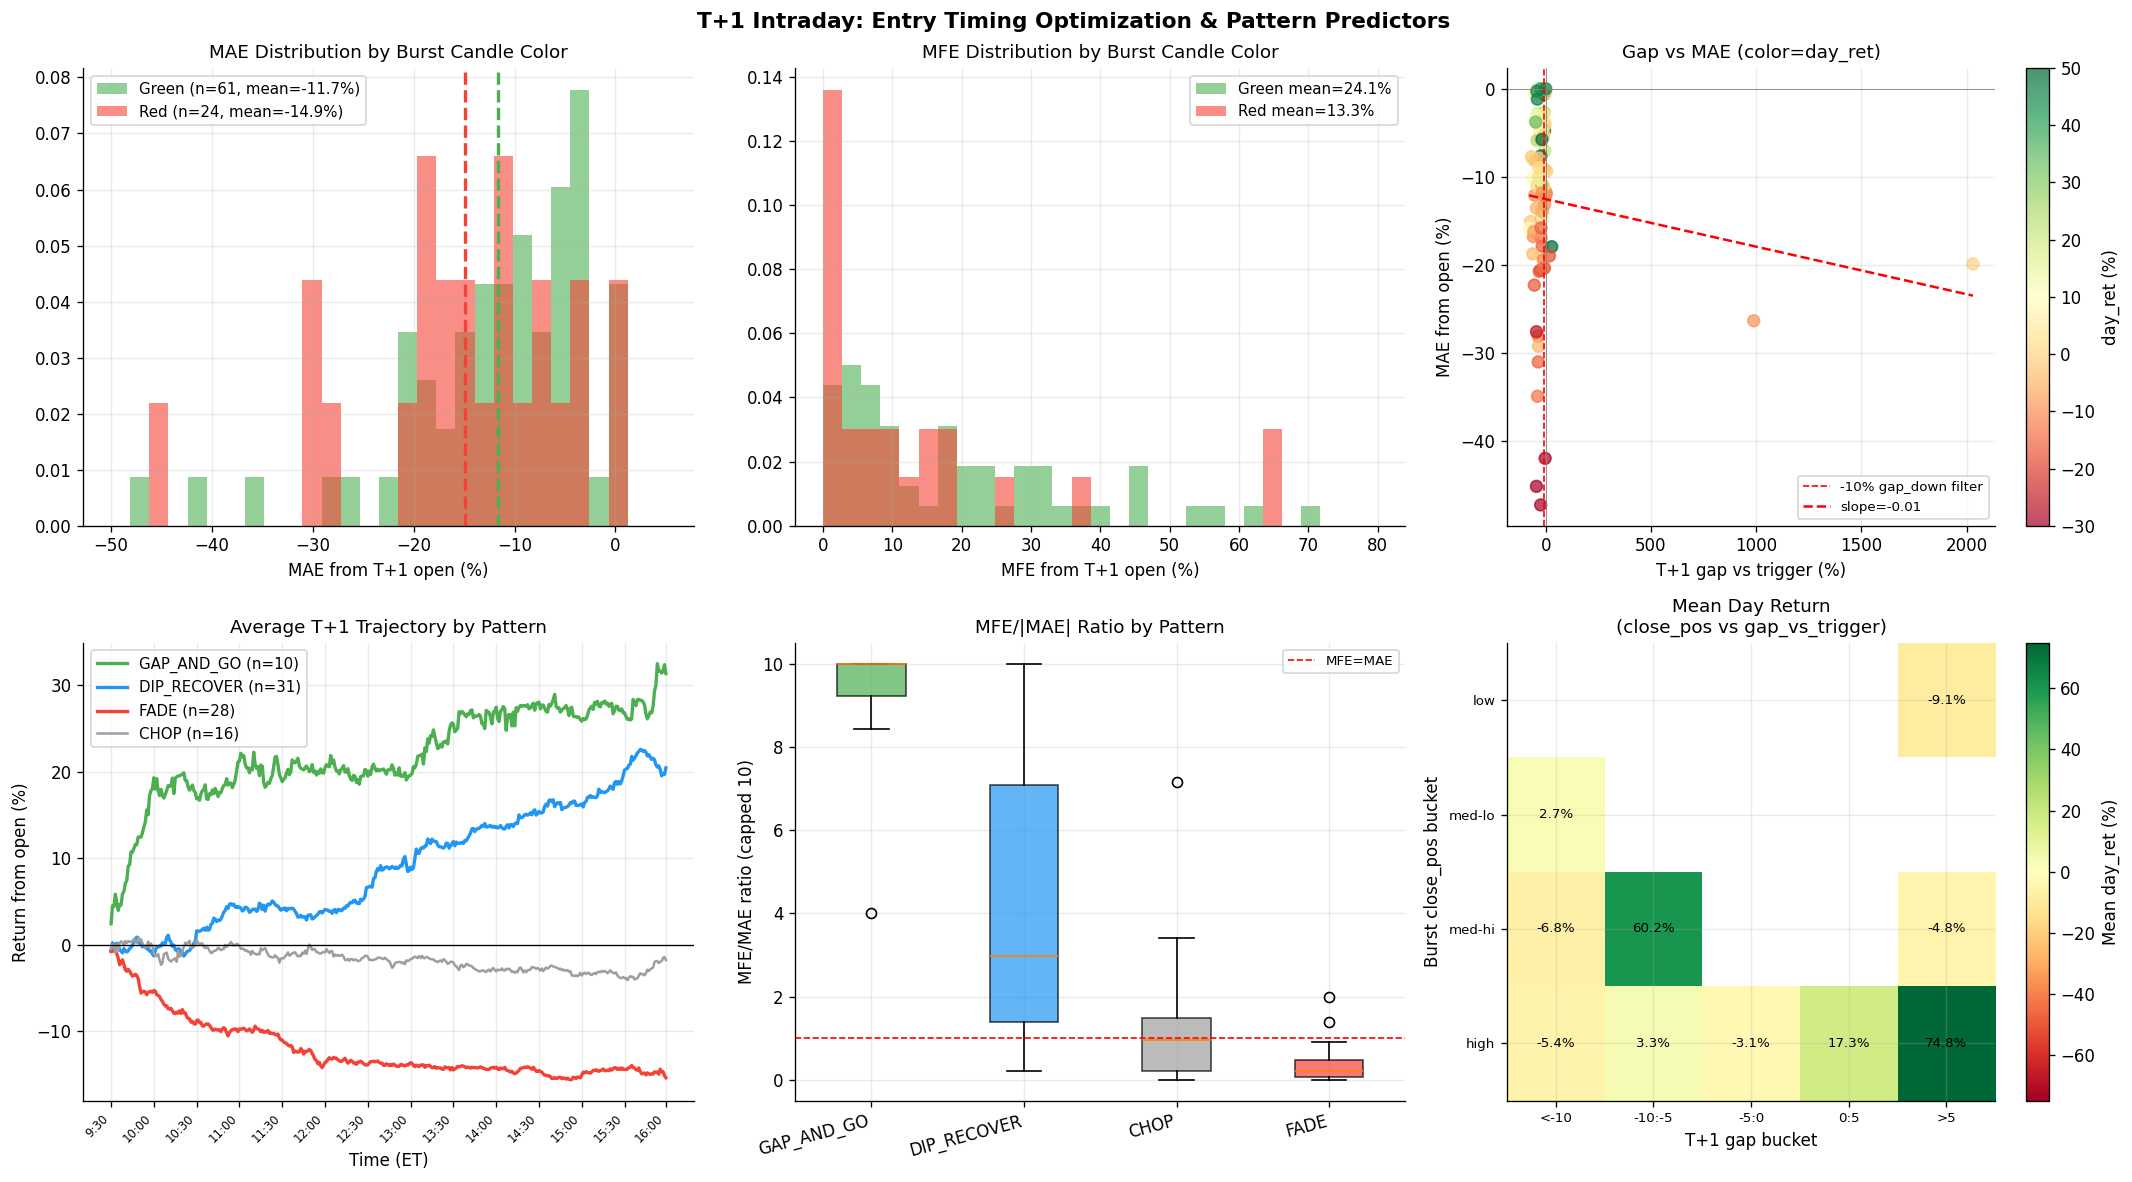

In [191]:
# ── Entry Timing & Pattern Predictors Visualization ──────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('T+1 Intraday: Entry Timing Optimization & Pattern Predictors', fontweight='bold')

# ── MAE distribution by candle_green ────────────────────────────────────────
ax = axes[0][0]
green  = intra[intra['candle_green'].astype(bool)]['mae'].dropna()
red    = intra[intra['candle_green'].astype(bool) == False]['mae'].dropna()
bins   = np.linspace(-50, 5, 30)
ax.hist(green, bins=bins, alpha=0.6, color='#4CAF50', density=True, label=f'Green (n={len(green)}, mean={green.mean():.1f}%)')
ax.hist(red,   bins=bins, alpha=0.6, color='#F44336', density=True, label=f'Red (n={len(red)}, mean={red.mean():.1f}%)')
ax.axvline(green.mean(), color='#4CAF50', linewidth=2, linestyle='--')
ax.axvline(red.mean(),   color='#F44336', linewidth=2, linestyle='--')
ax.set_title('MAE Distribution by Burst Candle Color')
ax.set_xlabel('MAE from T+1 open (%)')
ax.legend(fontsize=9)

# ── MFE distribution by candle_green ────────────────────────────────────────
ax = axes[0][1]
green_mfe = intra[intra['candle_green'].astype(bool)]['mfe'].dropna()
red_mfe   = intra[intra['candle_green'].astype(bool) == False]['mfe'].dropna()
bins_mfe  = np.linspace(0, 80, 30)
ax.hist(green_mfe, bins=bins_mfe, alpha=0.6, color='#4CAF50', density=True, label=f'Green mean={green_mfe.mean():.1f}%')
ax.hist(red_mfe,   bins=bins_mfe, alpha=0.6, color='#F44336', density=True, label=f'Red mean={red_mfe.mean():.1f}%')
ax.set_title('MFE Distribution by Burst Candle Color')
ax.set_xlabel('MFE from T+1 open (%)')
ax.legend(fontsize=9)

# ── MAE vs gap_vs_trigger scatter ────────────────────────────────────────────
ax = axes[0][2]
valid = intra.dropna(subset=['gap_vs_trigger','mae'])
sc = ax.scatter(valid['gap_vs_trigger'], valid['mae'],
                c=valid['day_ret'].clip(-30,50), cmap='RdYlGn',
                alpha=0.7, s=50, vmin=-30, vmax=50)
plt.colorbar(sc, ax=ax, label='day_ret (%)')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.axvline(-10, color='red', linewidth=1, linestyle='--', label='-10% gap_down filter')
z = np.polyfit(valid['gap_vs_trigger'], valid['mae'], 1)
xr = np.linspace(valid['gap_vs_trigger'].min(), valid['gap_vs_trigger'].max(), 50)
ax.plot(xr, np.poly1d(z)(xr), 'r--', linewidth=1.5, label=f'slope={z[0]:.2f}')
ax.set_xlabel('T+1 gap vs trigger (%)')
ax.set_ylabel('MAE from open (%)')
ax.set_title('Gap vs MAE (color=day_ret)')
ax.legend(fontsize=8)

# ── Average intraday profile by pattern ──────────────────────────────────────
ax = axes[1][0]
for pat, col, lw in [('GAP_AND_GO','#4CAF50',2),('DIP_RECOVER','#2196F3',2),
                      ('FADE','#F44336',2),('CHOP','#9E9E9E',1.5)]:
    pat_rows = intra[intra['pattern']==pat]
    curves = []
    for _, r in pat_rows.iterrows():
        df = get_intra(r['ticker'], r['t1_date'])
        if df.empty: continue
        opx = df['open'].iloc[0]
        if opx <= 0: continue
        ret = ((df['close'] - opx) / opx * 100).values
        curves.append(ret)
    if curves:
        min_len = min(len(c) for c in curves)
        avg = np.mean([c[:min_len] for c in curves], axis=0)
        ax.plot(range(min_len), avg, color=col, linewidth=lw, label=f'{pat} (n={len(curves)})')
ax.axhline(0, color='black', linewidth=0.8)
tick_min = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 389]
tick_lbl = ['9:30','10:00','10:30','11:00','11:30','12:00','12:30','13:00','13:30','14:00','14:30','15:00','15:30','16:00']
ax.set_xticks(tick_min)
ax.set_xticklabels(tick_lbl, rotation=45, ha='right', fontsize=7)
ax.set_xlabel('Time (ET)')
ax.set_ylabel('Return from open (%)')
ax.set_title('Average T+1 Trajectory by Pattern')
ax.legend(fontsize=9)

# ── MFE/MAE ratio by pattern ─────────────────────────────────────────────────
ax = axes[1][1]
ratio_data = [intra[intra['pattern']==p]['mfe_mae_ratio'].dropna().clip(0,10) for p in pat_order if p in intra['pattern'].values]
bp = ax.boxplot(ratio_data, labels=[p for p in pat_order if p in intra['pattern'].values],
                patch_artist=True, notch=False)
for patch, lbl in zip(bp['boxes'], [p for p in pat_order if p in intra['pattern'].values]):
    patch.set_facecolor(PAT_COLORS[lbl]); patch.set_alpha(0.7)
ax.axhline(1, color='red', linewidth=1, linestyle='--', label='MFE=MAE')
ax.set_ylabel('MFE/MAE ratio (capped 10)')
ax.set_title('MFE/|MAE| Ratio by Pattern')
ax.set_xticklabels([p for p in pat_order if p in intra['pattern'].values], rotation=15, ha='right')
ax.legend(fontsize=8)

# ── Heatmap: close_pos bucket × gap bucket → day_ret ─────────────────────────
ax = axes[1][2]
intra['gap_bucket']  = pd.cut(intra['gap_vs_trigger'].clip(-15,10),
                               bins=[-15,-10,-5,0,5,10], labels=['<-10','-10:-5','-5:0','0:5','>5'])
intra['cp_bucket']   = pd.cut(intra['close_pos'].clip(0,1),
                               bins=[0,0.3,0.5,0.7,1.0], labels=['low','med-lo','med-hi','high'])
pivot = intra.groupby(['cp_bucket','gap_bucket'])['day_ret'].mean().unstack()
if not pivot.empty:
    vmax = pivot.abs().max().max() if not pivot.empty else 10
    im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns.astype(str), fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index.astype(str), fontsize=8)
    plt.colorbar(im, ax=ax, label='Mean day_ret (%)')
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i,j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.1f}%', ha='center', va='center', fontsize=8)
    ax.set_title('Mean Day Return\n(close_pos vs gap_vs_trigger)')
    ax.set_xlabel('T+1 gap bucket')
    ax.set_ylabel('Burst close_pos bucket')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'v2_fig11_intraday_patterns.png', bbox_inches='tight')
plt.show()

In [192]:
# ── Intraday Edge Summary ─────────────────────────────────────────────────────
from scipy.stats import ttest_1samp

print('=' * 65)
print('INTRADAY T+1 EDGE SUMMARY')
print('=' * 65)
print(f'Events with intraday data: {len(intra)}')
print()

print('--- PATTERN BREAKDOWN ---')
for pat in ['GAP_AND_GO','DIP_RECOVER','CHOP','FADE']:
    s = intra[intra['pattern']==pat]
    if len(s) < 2: continue
    wr = (s['day_ret'] > 0).mean()
    print(f'  {pat:15s}: n={len(s):3d} ({len(s)/len(intra):.0%})  '
          f'day_ret mean={s["day_ret"].mean():+.1f}%  WR={wr:.0%}  '
          f'MFE mean={s["mfe"].mean():.1f}%  MAE mean={s["mae"].mean():.1f}%')

print()
print('--- MFE/MAE OVERALL ---')
print(f'  Mean MFE from open: {intra["mfe"].mean():.1f}%  (median {intra["mfe"].median():.1f}%)')
print(f'  Mean MAE from open: {intra["mae"].mean():.1f}%  (median {intra["mae"].median():.1f}%)')
print(f'  MFE/MAE ratio > 1: {(intra["mfe_mae_ratio"]>1).sum()} / {intra["mfe_mae_ratio"].notna().sum()} events')
print(f'  Time of MAE: median at minute {intra["mae_minute"].median():.0f} (~{9+(intra["mae_minute"].median()+30)//60:.0f}:{(int(intra["mae_minute"].median())+30)%60:02d} ET)')
print(f'  Time of MFE: median at minute {intra["mfe_minute"].median():.0f} (~{9+(intra["mfe_minute"].median()+30)//60:.0f}:{(int(intra["mfe_minute"].median())+30)%60:02d} ET)')

print()
print('--- DIP-RECOVER EDGE (dip entry = first-hour low) ---')
dr = intra[intra['pattern']=='DIP_RECOVER']
if len(dr) >= 5:
    open_ret = dr['day_ret'].dropna()
    dip_ret  = dr['dip_entry_ret'].dropna()
    _, p_open = ttest_1samp(open_ret, 0)
    _, p_dip  = ttest_1samp(dip_ret, 0)
    print(f'  n={len(dr)} events')
    print(f'  Open entry:      mean={open_ret.mean():+.1f}% WR={(open_ret>0).mean():.0%} p={p_open:.4f}')
    print(f'  Dip entry (1h-low): mean={dip_ret.mean():+.1f}% WR={(dip_ret>0).mean():.0%} p={p_dip:.4f}')

print()
print('--- KEY FINDINGS ---')
print('  1. MAE first, MFE after: check mae_minute < mfe_minute')
print('     Pct where MAE comes before MFE:', end=' ')
before = (intra['mae_minute'] < intra['mfe_minute']).mean()
print(f'{before:.0%}')
print(f'  2. Mean MAE before MFE: {intra[intra["mae_minute"]<intra["mfe_minute"]]["mae"].mean():.1f}%')
print(f'  3. If we could enter at the MAE low, mean return to close: '
      f'{((intra["t1_close"] - intra.apply(lambda r: get_intra(r["ticker"],r["t1_date"]).get("low", pd.Series([np.nan])).min() if not get_intra(r["ticker"],r["t1_date"]).empty else np.nan, axis=1)) / intra.apply(lambda r: get_intra(r["ticker"],r["t1_date"]).get("low", pd.Series([np.nan])).min() if not get_intra(r["ticker"],r["t1_date"]).empty else np.nan, axis=1) * 100).mean():.1f}% (ideal, not tradeable)')
print()
print('  Actionable: entry at open on GREEN burst days')
green_ev = intra[intra['candle_green'].astype(bool)]
_, p_g = ttest_1samp(green_ev['day_ret'].dropna(), 0)
print(f'  Green candle: n={len(green_ev)} mean={green_ev["day_ret"].mean():+.1f}% WR={(green_ev["day_ret"]>0).mean():.0%} p={p_g:.4f}')

INTRADAY T+1 EDGE SUMMARY
Events with intraday data: 85

--- PATTERN BREAKDOWN ---
  GAP_AND_GO     : n= 10 (12%)  day_ret mean=+31.4%  WR=100%  MFE mean=42.0%  MAE mean=-1.1%
  DIP_RECOVER    : n= 31 (36%)  day_ret mean=+20.4%  WR=100%  MFE mean=33.1%  MAE mean=-8.7%
  CHOP           : n= 16 (19%)  day_ret mean=-1.8%  WR=6%  MFE mean=9.6%  MAE mean=-11.1%
  FADE           : n= 28 (33%)  day_ret mean=-15.4%  WR=0%  MFE mean=6.9%  MAE mean=-21.9%

--- MFE/MAE OVERALL ---
  Mean MFE from open: 21.1%  (median 11.7%)
  Mean MAE from open: -12.6%  (median -11.0%)
  MFE/MAE ratio > 1: 42 / 82 events
  Time of MAE: median at minute 53 (~10:23 ET)
  Time of MFE: median at minute 97 (~11:07 ET)

--- DIP-RECOVER EDGE (dip entry = first-hour low) ---
  n=31 events
  Open entry:      mean=+20.4% WR=100% p=0.0001
  Dip entry (1h-low): mean=+31.1% WR=100% p=0.0000

--- KEY FINDINGS ---
  1. MAE first, MFE after: check mae_minute < mfe_minute
     Pct where MAE comes before MFE: 55%
  2. Mean MAE bef

Events loaded: 85

=== STOP LEVEL ANALYSIS ===
 Threshold  N touched  % universe  % recovered   % faded  mean final  mean marginal
-------------------------------------------------------------------------------------
        0%         85      100.0%        49.4%     32.9%       +5.7%          +8.1%
       -1%         78       91.8%        44.9%     35.9%       +3.4%          +6.7%
       -2%         77       90.6%        44.2%     36.4%       +2.8%          +7.3%
       -3%         74       87.1%        41.9%     37.8%       +2.3%          +7.6%
       -5%         63       74.1%        33.3%     44.4%       +0.2%          +7.4%
       -7%         58       68.2%        31.0%     48.3%       -1.9%          +7.4%
       -8%         54       63.5%        29.6%     51.9%       -3.9%          +6.5%
      -10%         48       56.5%        27.1%     58.3%       -4.8%          +7.4%
      -12%         37       43.5%        16.2%     70.3%       -7.9%          +6.8%
      -15%         28      

2026-04-14 08:04:39,932 matplotlib.font_manager DEBUG findfont: Matching sans\-serif:style=normal:variant=normal:weight=bold:stretch=normal:size=14.0.
2026-04-14 08:04:39,933 matplotlib.font_manager DEBUG findfont: score(FontEntry(fname='/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Bold.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 0.05
2026-04-14 08:04:39,934 matplotlib.font_manager DEBUG findfont: score(FontEntry(fname='/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniBol.ttf', name='STIXNonUnicode', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.05
2026-04-14 08:04:39,934 matplotlib.font_manager DEBUG findfont: score(FontEntry(fname='/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/mpl-data/font

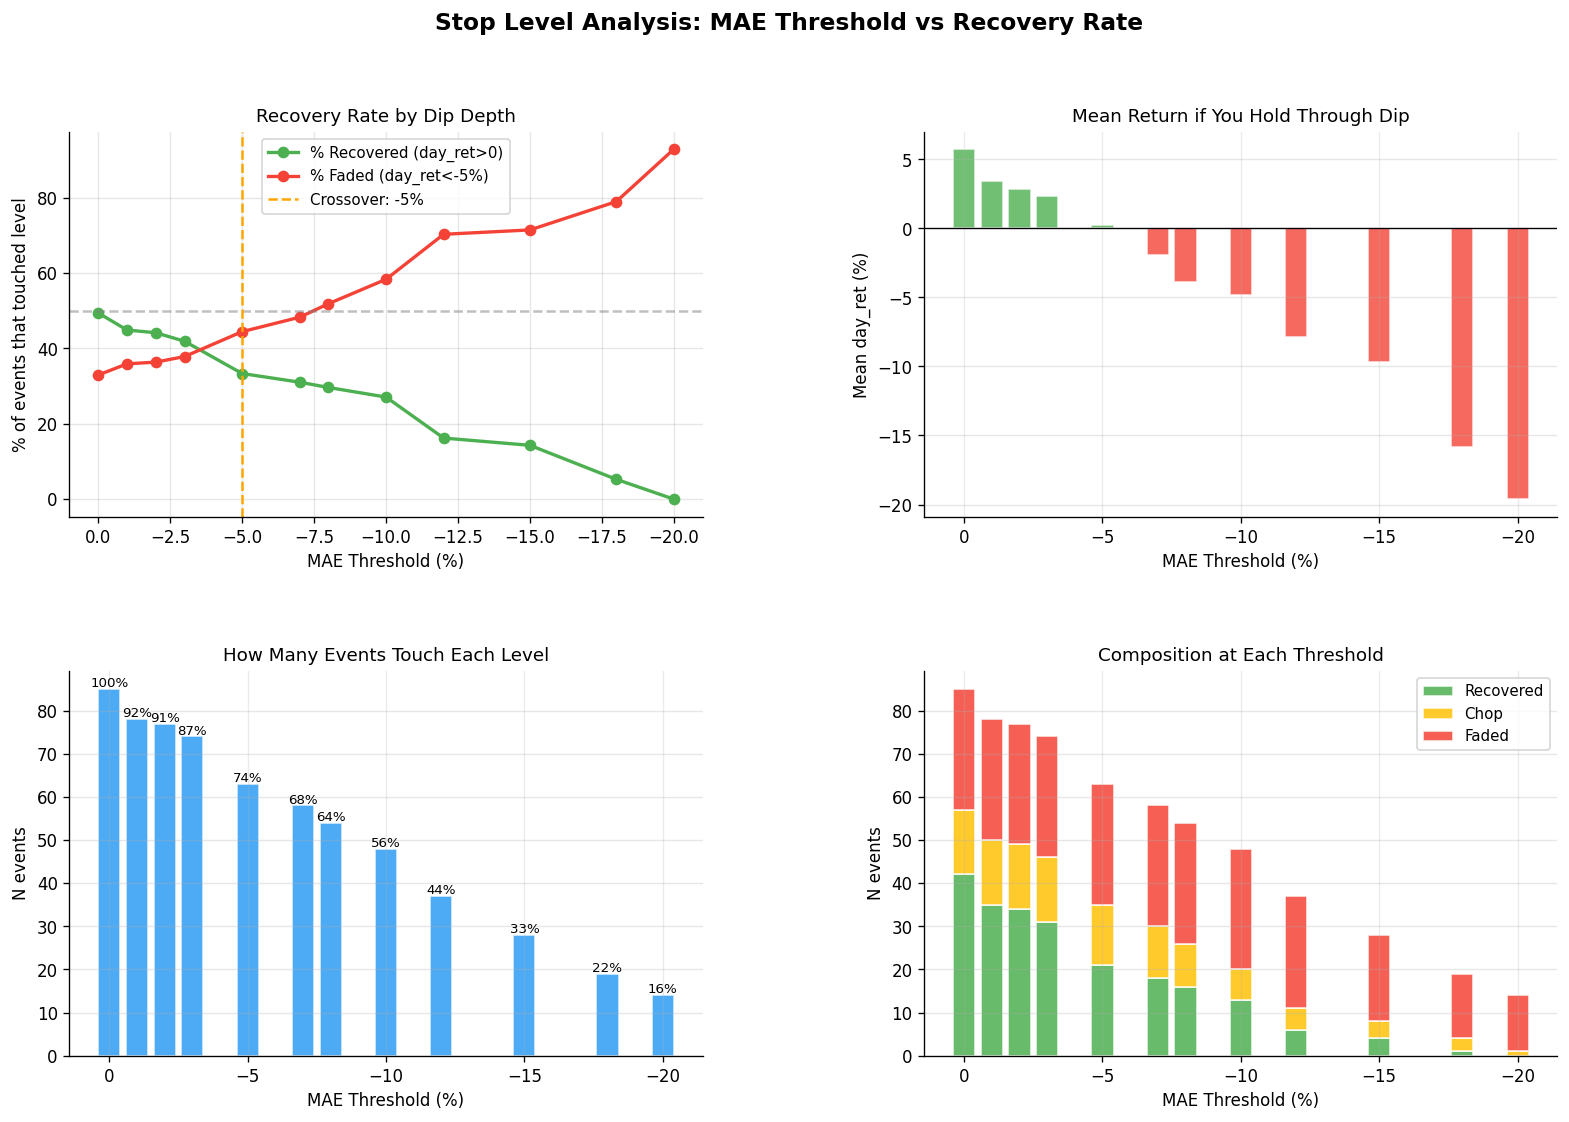


Chart saved.

=== KEY INSIGHT ===
Recovery > Fade up to threshold: -3%
  → At -3%: 42% recover, 38% fade

Crossover at -5%: below this level, more events fade than recover
  → Optimal stop-loss: between -5% and -3% from entry

N=85 events — treat as directional evidence, not definitive rule (13 days only)


In [193]:
# ── Stop Level Analysis: MAE threshold → survival rate ──────────────────────
# For each MAE threshold, what % of events that touched that level
# ended as DIP_RECOVER (recovered) vs FADE (kept falling)?
# This gives the empirically optimal stop-loss level.

import sqlite3 as _sq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import chi2_contingency

INTRA_CACHE = ANALYSIS_DIR / 'burst_intraday_cache.db'

# ── Load intraday bars ────────────────────────────────────────────────────────
_ic = _sq.connect(str(INTRA_CACHE))

records = []
for _, ev_row in intra.iterrows():
    sym   = ev_row['ticker']
    t1d   = ev_row['t1_date']
    bars  = pd.read_sql(
        "SELECT dt, open, high, low, close, volume FROM bars WHERE symbol=? AND date=? ORDER BY dt",
        _ic, params=(sym, t1d)
    )
    if bars.empty:
        continue
    open_px = bars.iloc[0]['open']
    if open_px <= 0:
        continue
    pattern = ev_row['pattern']
    day_ret = ev_row['day_ret']

    # Compute running MAE (pct from open) at each minute
    bars['pct_from_open'] = (bars['low'] - open_px) / open_px * 100
    running_mae = bars['pct_from_open'].cummin()

    records.append({
        'ticker':   sym,
        'date':     t1d,
        'pattern':  pattern,
        'day_ret':  day_ret,
        'open':     open_px,
        'bars':     bars,
        'running_mae': running_mae,
    })

_ic.close()
print(f"Events loaded: {len(records)}")

# ── For each MAE threshold, compute survival stats ────────────────────────────
thresholds = [0, -1, -2, -3, -5, -7, -8, -10, -12, -15, -18, -20]

rows = []
for thresh in thresholds:
    # Events that touched this MAE level at any point during the day
    touched = [r for r in records if r['running_mae'].min() <= thresh]
    n_touched = len(touched)
    if n_touched == 0:
        continue

    recovered  = [r for r in touched if r['day_ret'] > 0]        # DIP_RECOVER or GAP_AND_GO
    faded      = [r for r in touched if r['day_ret'] <= -5]       # FADE
    chopped    = [r for r in touched if -5 < r['day_ret'] <= 0]   # CHOP

    n_rec  = len(recovered)
    n_fade = len(faded)
    n_chop = len(chopped)

    # Mean final return if you held after touching threshold
    mean_final = np.mean([r['day_ret'] for r in touched])

    # Mean return from threshold to close (marginal return after the dip)
    marginal_rets = []
    for r in touched:
        bars = r['bars']
        # Find first bar where running MAE reaches threshold
        mask = ((bars['low'] - r['open']) / r['open'] * 100) <= thresh
        if not mask.any():
            continue
        first_bar_idx = mask.idxmax()
        entry_px = bars.loc[first_bar_idx, 'low']  # best case entry at the low
        close_px = bars.iloc[-1]['close']
        if entry_px > 0:
            marginal_rets.append((close_px - entry_px) / entry_px * 100)

    mean_marginal = np.mean(marginal_rets) if marginal_rets else np.nan

    rows.append({
        'threshold':     thresh,
        'n_touched':     n_touched,
        'pct_touched':   n_touched / len(records) * 100,
        'n_recovered':   n_rec,
        'n_faded':       n_fade,
        'n_chopped':     n_chop,
        'pct_recovered': n_rec / n_touched * 100,
        'pct_faded':     n_fade / n_touched * 100,
        'mean_final_ret': mean_final,
        'mean_marginal_ret': mean_marginal,
    })

stop_df = pd.DataFrame(rows)

print("\n=== STOP LEVEL ANALYSIS ===")
print(f"{'Threshold':>10}  {'N touched':>9}  {'% universe':>10}  {'% recovered':>11}  {'% faded':>8}  {'mean final':>10}  {'mean marginal':>13}")
print('-' * 85)
for _, r in stop_df.iterrows():
    print(f"  {r['threshold']:>7.0f}%  {r['n_touched']:>9.0f}  {r['pct_touched']:>9.1f}%  "
          f"{r['pct_recovered']:>10.1f}%  {r['pct_faded']:>7.1f}%  "
          f"{r['mean_final_ret']:>+9.1f}%  {r['mean_marginal_ret']:>+12.1f}%")

# ── Visualization ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Stop Level Analysis: MAE Threshold vs Recovery Rate', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Panel 1: % recovered vs % faded by threshold
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(stop_df['threshold'], stop_df['pct_recovered'], 'o-', color='#4CAF50', linewidth=2, label='% Recovered (day_ret>0)')
ax1.plot(stop_df['threshold'], stop_df['pct_faded'],     'o-', color='#F44336', linewidth=2, label='% Faded (day_ret<-5%)')
ax1.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('MAE Threshold (%)')
ax1.set_ylabel('% of events that touched level')
ax1.set_title('Recovery Rate by Dip Depth')
ax1.legend(fontsize=9)
ax1.invert_xaxis()
ax1.grid(True, alpha=0.3)

# Add vertical line at crossover point (where recovery < fade)
cross = stop_df[stop_df['pct_recovered'] < stop_df['pct_faded']]
if not cross.empty:
    cross_thresh = cross.iloc[0]['threshold']
    ax1.axvline(cross_thresh, color='orange', linestyle='--', linewidth=1.5, label=f'Crossover: {cross_thresh:.0f}%')
    ax1.legend(fontsize=9)

# Panel 2: Mean final return if held through dip
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(stop_df['threshold'], stop_df['mean_final_ret'],
        color=['#4CAF50' if x > 0 else '#F44336' for x in stop_df['mean_final_ret']],
        alpha=0.8, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('MAE Threshold (%)')
ax2.set_ylabel('Mean day_ret (%)')
ax2.set_title('Mean Return if You Hold Through Dip')
ax2.invert_xaxis()
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: N events touched vs threshold
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(stop_df['threshold'], stop_df['n_touched'], color='#2196F3', alpha=0.8, edgecolor='white')
ax3.set_xlabel('MAE Threshold (%)')
ax3.set_ylabel('N events')
ax3.set_title('How Many Events Touch Each Level')
ax3.invert_xaxis()
ax3.grid(True, alpha=0.3, axis='y')
for _, r in stop_df.iterrows():
    ax3.text(r['threshold'], r['n_touched'] + 0.5, f"{r['pct_touched']:.0f}%", ha='center', fontsize=8)

# Panel 4: Stacked bar — composition at each threshold
ax4 = fig.add_subplot(gs[1, 1])
bottoms = np.zeros(len(stop_df))
for col, color, label in [
    ('n_recovered', '#4CAF50', 'Recovered'),
    ('n_chopped',   '#FFC107', 'Chop'),
    ('n_faded',     '#F44336', 'Faded'),
]:
    vals = stop_df[col].values
    ax4.bar(stop_df['threshold'], vals, bottom=bottoms, color=color, alpha=0.85, label=label, edgecolor='white')
    bottoms += vals
ax4.set_xlabel('MAE Threshold (%)')
ax4.set_ylabel('N events')
ax4.set_title('Composition at Each Threshold')
ax4.legend(fontsize=9)
ax4.invert_xaxis()
ax4.grid(True, alpha=0.3, axis='y')

plt.savefig(str(ANALYSIS_DIR / 'stop_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved.")

# ── Key insight ───────────────────────────────────────────────────────────────
print("\n=== KEY INSIGHT ===")
best_row = stop_df[stop_df['pct_recovered'] >= stop_df['pct_faded']].iloc[-1] if not cross.empty else stop_df.iloc[-1]
print(f"Recovery > Fade up to threshold: {best_row['threshold']:.0f}%")
print(f"  → At -{abs(best_row['threshold']):.0f}%: {best_row['pct_recovered']:.0f}% recover, {best_row['pct_faded']:.0f}% fade")
if not cross.empty:
    print(f"\nCrossover at {cross_thresh:.0f}%: below this level, more events fade than recover")
    print(f"  → Optimal stop-loss: between {cross_thresh:.0f}% and {cross_thresh+2:.0f}% from entry")
print(f"\nN=85 events — treat as directional evidence, not definitive rule (13 days only)")


## 10. Executive Summary & Verdict

In [194]:
# ── Ensure ev is defined (safe to re-run) ───────────────────────
ev = events.copy()
ev['gap_ok']     = ev['T1_gap'].isna() | (ev['T1_gap'] > -10)
ev['hi_ibkr']    = ev['ibkr_chg'] >= 30
ev['hi_persist'] = ev['presence_pct'] >= 0.60

# ── Final Summary ────────────────────────────────────────────────────────────
from scipy.stats import ttest_1samp

print('=' * 70)
print('FINVIZ BURST → T+1..T+9 ANALYSIS — EXECUTIVE SUMMARY (v2)')
print('=' * 70)
print(f'Universe: {len(events)} burst events across {events["burst_date"].nunique()} days')
print(f'Date range: 2026-03-24 → 2026-04-13 (13 trading days)')
print(f'Threshold: presence >= {PRESENCE_THRESH:.0%} of daily snapshots, n_snaps >= {MIN_SNAPS}')
print()

print('--- H1: MOMENTUM CONTINUATION (open entry, T+1) ---')
for label, subset in [
    ('All events',                             ev),
    ('Green candle',                           ev[ev['candle_green'].astype(bool)]),
    ('Green + close_pos >= 0.7',               ev[(ev['candle_green'].astype(bool)) & (ev['close_pos']>=0.7)]),
    ('Green + gap_ok + presence>=60%',         ev[(ev['candle_green'].astype(bool)) & ev['gap_ok'] & ev['hi_persist']]),
    ('Best combo (green+gap+persist+ibkr≥30)', ev[(ev['candle_green'].astype(bool)) & ev['gap_ok'] & ev['hi_persist'] & ev['hi_ibkr']]),
]:
    s = subset['T1_ret_open'].dropna()
    if len(s) < 3:
        continue
    _, p = ttest_1samp(s, 0)
    pf = s[s>0].sum() / abs(s[s<0].sum()) if s[s<0].sum() != 0 else float('inf')
    sig = ' *** SIGNIFICANT' if p < 0.05 else (' (trending)' if p < 0.15 else '')
    print(f'  {label:50s}: n={len(s):3d} WR={((s>0).mean()):.0%} mean={s.mean():+.1f}% PF={pf:.2f} p={p:.4f}{sig}')

print()
print('--- TRIGGER HIT RATE (conditional scenario A) ---')
for t in [1, 2, 3]:
    trig_col = f'T{t}_triggered'
    hr = events[trig_col].dropna().mean()
    sa = events[f'T{t}_ret_trigger'].dropna()
    if len(sa) >= 3:
        _, p = ttest_1samp(sa, 0)
        print(f'  T+{t}: hit_rate={hr:.0%} → conditional n={len(sa)} mean={sa.mean():+.1f}% WR={((sa>0).mean()):.0%} p={p:.4f}')

print()
print('--- H5: BOUNCE DAY (prospective) ---')
if len(bounce_df) >= 5:
    fwd = bounce_df['fwd_ret'].dropna()
    _, p_b = ttest_1samp(fwd, 0)
    print(f'  Signals: {len(fwd)} | WR={((fwd>0).mean()):.0%} | mean={fwd.mean():.1f}% | p={p_b:.4f}')
else:
    print(f'  N insuficiente ({len(bounce_df)} signals)')

print()
print('--- CRITICAL CAVEATS ---')
print('  1. N=13 days — results are EXPLORATORY only, not confirmatory')
print('  2. All returns are GROSS — subtract ~$0.012/share/side for realistic TC')
print('  3. Finviz DB only exists for days when dashboard was running (selection bias)')
print('  4. Small-cap spreads can be 1-5%+ — slippage material on open entries')
print('  5. FDR correction applied to T+1..T+9 within each scenario')
print()
print(f'Run completed: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 70)

FINVIZ BURST → T+1..T+9 ANALYSIS — EXECUTIVE SUMMARY (v2)
Universe: 91 burst events across 13 days
Date range: 2026-03-24 → 2026-04-13 (13 trading days)
Threshold: presence >= 30% of daily snapshots, n_snaps >= 3

--- H1: MOMENTUM CONTINUATION (open entry, T+1) ---
  All events                                        : n= 80 WR=51% mean=+5.4% PF=2.04 p=0.0378 *** SIGNIFICANT
  Green candle                                      : n= 57 WR=54% mean=+7.2% PF=2.43 p=0.0291 *** SIGNIFICANT
  Green + close_pos >= 0.7                          : n= 26 WR=54% mean=+5.2% PF=1.98 p=0.2617
  Green + gap_ok + presence>=60%                    : n= 22 WR=55% mean=+5.7% PF=1.99 p=0.2988
  Best combo (green+gap+persist+ibkr≥30)            : n= 22 WR=55% mean=+5.7% PF=1.99 p=0.2988

--- TRIGGER HIT RATE (conditional scenario A) ---
  T+1: hit_rate=31% → conditional n=25 mean=+5.4% WR=44% p=0.3208
  T+2: hit_rate=31% → conditional n=21 mean=+5.6% WR=52% p=0.3991
  T+3: hit_rate=32% → conditional n=19 mean=